In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import functions_spin_p as fy
from importlib import reload

reload(fy)

<module 'functions_spin_p' from '/mnt/c/Users/frnkl/Desktop/thesis_spin_caloritronics/tesis_models/horizontal_model/functions_spin_p.py'>

In [2]:
#Parameters

energy_axis = np.arange(-20, 20 + 0.01, 0.01) #meV
print("Energy axis is", energy_axis,"meV")

#Gamma i.e. width parameter
gamma = 0.5 #meV
print("The width is:",gamma,"meV")

#Site energies:
e_1 = 0 #meV
e_2 = 0 #meV

print("The site (spin independent) energies are:", \
      e_1," meV and",e_2," meV")

Energy axis is [-20.   -19.99 -19.98 ...  19.99  20.    20.01] meV
The width is: 0.5 meV
The site (spin independent) energies are: 0  meV and 0  meV


In [3]:
#Define the \Delta parameter previously the definition of the Hamiltonian 

delta = 0 #meV

e_1_u = e_1 + delta #meV
e_1_d = e_1 - delta #meV
e_2_u = e_2 + delta #meV
e_2_d = e_2 - delta #meV
v = 4*gamma 
#v = 3

Hamiltonian = np.array([[e_1_u, 0 , v , 0],[0, e_1_d, 0, v], [v, 0, e_2_u, 0], [0, v, 0, e_2_d]], dtype = complex)

print(Hamiltonian)

[[0.+0.j 0.+0.j 2.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 2.+0.j]
 [2.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 2.+0.j 0.+0.j 0.+0.j]]


/home/franklin/miniconda3/envs/py37/lib/python3.7/site-packages/ipykernel_launcher.py:88: UserWarning: This figure was using constrained_layout, but that is incompatible with subplots_adjust and/or tight_layout; disabling constrained_layout.


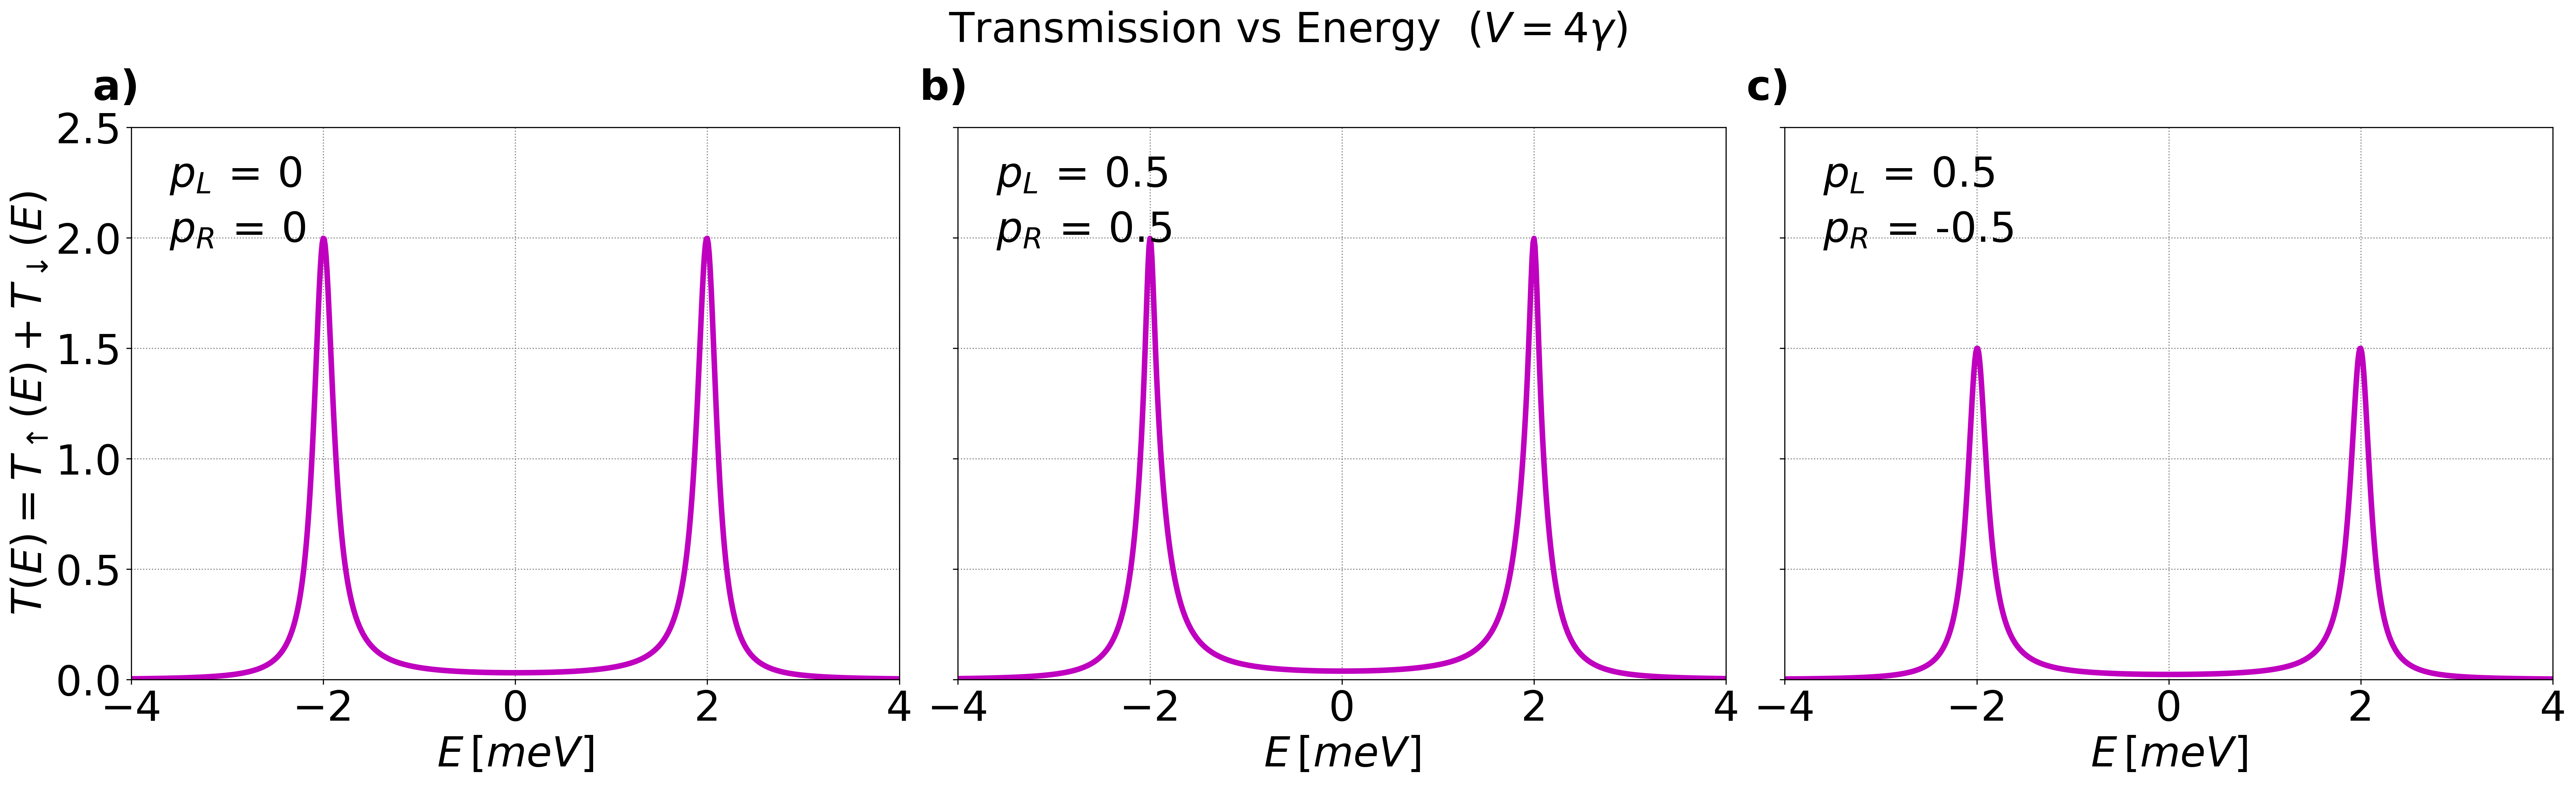

In [4]:
# do not forget constrained_layout=True to have some space between axes
fig = plt.figure(constrained_layout=True, figsize=(26,8), dpi=300)

# these are matplotlib.patch.Patch properties
props = dict(boxstyle='round', facecolor='wheat', alpha=0)

#Set the grid for the subplots
gs = GridSpec(1, 3, figure=fig)

#Add the subplots
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[0, 2])

#POLARIZATION = 0
# Transmission spin up Plot
p=0

ax1.grid(linestyle=':', color='grey')
ax1.plot(energy_axis, fy.Transmission(energy_axis, gamma, Hamiltonian, p, p)[0]\
     +fy.Transmission(energy_axis, gamma, Hamiltonian, p, p)[1], "m", lw=4)
ax1.set_xlabel(r'$E\,[meV]$',fontsize=30)
ax1.set_ylabel(r'$T(E) = T_{\uparrow}(E)+T_{\downarrow}(E)$',fontsize=30)
ax1.text(0.05, 0.95, r"$p_{L}\,=\,$"+str(p), transform=ax1.transAxes, fontsize=30,
        verticalalignment='top', bbox=props)
ax1.text(0.05, 0.85, r"$p_{R}\,=\,$"+str(p), transform=ax1.transAxes, fontsize=30,
        verticalalignment='top', bbox=props)
# Etiqueta a)
ax1.text(-0.05, 1.05, r'a)', transform=ax1.transAxes, fontsize=30, fontweight='bold')

t1=fy.Transmission(energy_axis, gamma, Hamiltonian, p, p)[0]\
     +fy.Transmission(energy_axis, gamma, Hamiltonian, p, p)[1]

p= 0.5
ax2.grid(linestyle=':', color='grey')
#ax2.plot(energy_axis, t1, "b", lw=4)
ax2.plot(energy_axis, fy.Transmission(energy_axis, gamma, Hamiltonian, p, p)[0]\
     +fy.Transmission(energy_axis, gamma, Hamiltonian, p, p)[1], "m", lw=4)
ax2.set_xlabel(r'$E\,[meV]$',fontsize=30)
#ax2.set_ylabel(r'$T(E) = T_{\uparrow}(E)+T_{\downarrow}(E)$',fontsize=18)
ax2.text(0.05, 0.95, r"$p_{L}\,=\,$"+str(p), transform=ax2.transAxes, fontsize=30,
        verticalalignment='top', bbox=props)
ax2.text(0.05, 0.85, r"$p_{R}\,=\,$"+str(p), transform=ax2.transAxes, fontsize=30,
        verticalalignment='top', bbox=props)
# Etiqueta c)
ax2.text(-0.05, 1.05, r'b)', transform=ax2.transAxes, fontsize=30, fontweight='bold')

k=0.5
p_L= k
p_R = -k

ax3.grid(linestyle=':', color='grey')
ax3.plot(energy_axis, fy.Transmission(energy_axis, gamma, Hamiltonian, p_L, p_R)[0]\
     +fy.Transmission(energy_axis, gamma, Hamiltonian, p_L, p_R)[1], "m", lw=4)
ax3.set_xlabel(r'$E\,[meV]$',fontsize=30)
#ax3.set_ylabel(r'$T(E) = T_{\uparrow}(E)+T_{\downarrow}(E)$',fontsize=18)
ax3.text(0.05, 0.95, r"$p_{L}\,=\,$"+str(p_L), transform=ax3.transAxes, fontsize=30,
        verticalalignment='top', bbox=props)
ax3.text(0.05, 0.85, r"$p_{R}\,=\,$"+str(p_R), transform=ax3.transAxes, fontsize=30,
        verticalalignment='top', bbox=props)
# Etiqueta c)
ax3.text(-0.05, 1.05, r'c)', transform=ax3.transAxes, fontsize=30, fontweight='bold')



# Stablish limits for the subplots
ax1.set_ylim(0, 2.5)  
ax2.set_ylim(0, 2.5)   
ax3.set_ylim(0, 2.5) 
ax1.set_xlim(-4, 4)  
ax2.set_xlim(-4, 4)   
ax3.set_xlim(-4, 4) 

# Set the fontsize for the x and y ticks
ax1.tick_params(axis='x', labelsize=30)
ax1.tick_params(axis='y', labelsize=30)
ax2.tick_params(axis='x', labelsize=30)
ax2.tick_params(axis='y', labelsize=30)
ax3.tick_params(axis='x', labelsize=30)
ax3.tick_params(axis='y', labelsize=30)

# Eliminar los números del eje x en el primer subplot
ax2.set_yticklabels([])
ax3.set_yticklabels([])

# Ajustar el diseño y mostrar los subplots
plt.suptitle("Transmission vs Energy "+r" ($V=$"+str(int(v/gamma))+r"$\gamma$)", fontsize=30)
plt.tight_layout()
plt.show()
#fig.savefig('horizontal_Transmission_polarization.jpg')

/home/franklin/miniconda3/envs/py37/lib/python3.7/site-packages/ipykernel_launcher.py:108: UserWarning: This figure was using constrained_layout, but that is incompatible with subplots_adjust and/or tight_layout; disabling constrained_layout.


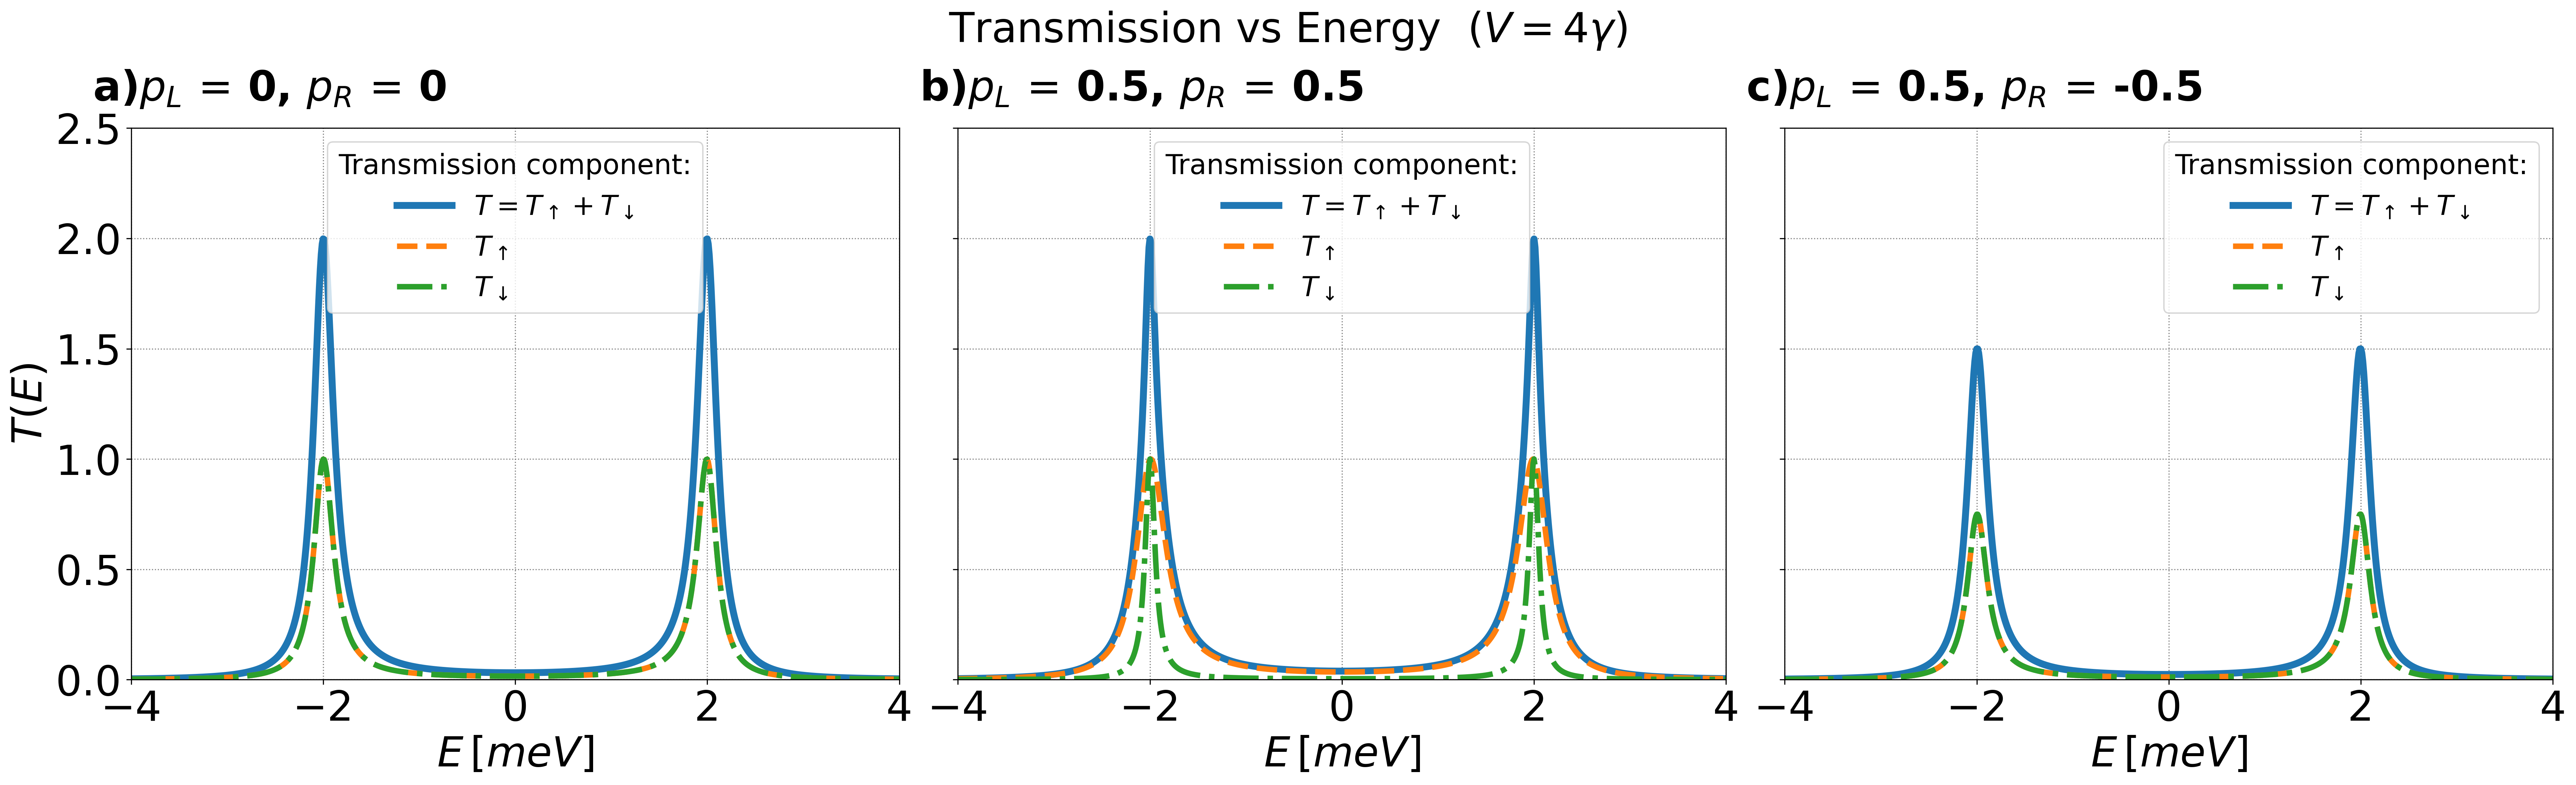

In [5]:
# do not forget constrained_layout=True to have some space between axes
fig = plt.figure(constrained_layout=True, figsize=(26,8), dpi=300)

# these are matplotlib.patch.Patch properties
props = dict(boxstyle='round', facecolor='wheat', alpha=0)

#Set the grid for the subplots
gs = GridSpec(1, 3, figure=fig)

#Add the subplots
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[0, 2])

#POLARIZATION = 0
# Transmission spin up Plot
p=0

ax1.grid(linestyle=':', color='grey')
ax1.plot(energy_axis, fy.Transmission(energy_axis, gamma, Hamiltonian, p, p)[0]\
     +fy.Transmission(energy_axis, gamma, Hamiltonian, p, p)[1], "#1f77b4", lw=5, label=r"$T=T_{\uparrow}+T_{\downarrow}$")
ax1.plot(energy_axis, fy.Transmission(energy_axis, gamma, Hamiltonian, p, p)[0], "#ff7f0e", lw=4, linestyle="--", label=r"$T_{\uparrow}$")
ax1.plot(energy_axis, fy.Transmission(energy_axis, gamma, Hamiltonian, p, p)[1], "#2ca02c", lw=4, linestyle="-.", label=r"$T_{\downarrow}$")
ax1.set_xlabel(r'$E\,[meV]$',fontsize=30)
ax1.set_ylabel(r'$T(E)$',fontsize=30)
# ax1.text(0.05, 0.95, r"$p_{L}\,=\,$"+str(p), transform=ax1.transAxes, fontsize=30,
#         verticalalignment='top', bbox=props)
# ax1.text(0.05, 0.85, r"$p_{R}\,=\,$"+str(p), transform=ax1.transAxes, fontsize=30,
#         verticalalignment='top', bbox=props)
# Etiqueta a)
ax1.text(-0.05, 1.05, r'a)'+r"$p_{L}\,=\,$"+str(p)+r", $p_{R}\,=\,$"+str(p), transform=ax1.transAxes, fontsize=30, fontweight='bold')
ax1.legend(
    fontsize=20,
    title="Transmission component:",
    title_fontsize=20
)

# t1=fy.Transmission(energy_axis, gamma, Hamiltonian, p, p)[0]\
#      +fy.Transmission(energy_axis, gamma, Hamiltonian, p, p)[1]

p= 0.5
ax2.grid(linestyle=':', color='grey')
#ax2.plot(energy_axis, t1, "b", lw=4)
ax2.plot(energy_axis, fy.Transmission(energy_axis, gamma, Hamiltonian, p, p)[0]\
     +fy.Transmission(energy_axis, gamma, Hamiltonian, p, p)[1], "#1f77b4", lw=5, label=r"$T=T_{\uparrow}+T_{\downarrow}$")
ax2.plot(energy_axis, fy.Transmission(energy_axis, gamma, Hamiltonian, p, p)[0], "#ff7f0e", lw=4, linestyle="--", label=r"$T_{\uparrow}$")
ax2.plot(energy_axis, fy.Transmission(energy_axis, gamma, Hamiltonian, p, p)[1], "#2ca02c", lw=4, linestyle="-.", label=r"$T_{\downarrow}$")
ax2.set_xlabel(r'$E\,[meV]$',fontsize=30)
#ax2.set_ylabel(r'$T(E) = T_{\uparrow}(E)+T_{\downarrow}(E)$',fontsize=18)
# ax2.text(0.05, 0.95, r"$p_{L}\,=\,$"+str(p), transform=ax2.transAxes, fontsize=30,
#         verticalalignment='top', bbox=props)
# ax2.text(0.05, 0.85, r"$p_{R}\,=\,$"+str(p), transform=ax2.transAxes, fontsize=30,
#         verticalalignment='top', bbox=props)
# Etiqueta b)
ax2.text(-0.05, 1.05, r'b)'+r"$p_{L}\,=\,$"+str(p)+r", $p_{R}\,=\,$"+str(p), transform=ax2.transAxes, fontsize=30, fontweight='bold')
ax2.legend(
    fontsize=20,
    title="Transmission component:",
    title_fontsize=20
)

k=0.5
p_L= k
p_R = -k

ax3.grid(linestyle=':', color='grey')
ax3.plot(energy_axis, fy.Transmission(energy_axis, gamma, Hamiltonian, p_L, p_R)[0]\
     +fy.Transmission(energy_axis, gamma, Hamiltonian, p_L, p_R)[1], "#1f77b4", lw=5, label=r"$T=T_{\uparrow}+T_{\downarrow}$")
ax3.plot(energy_axis, fy.Transmission(energy_axis, gamma, Hamiltonian, p_L, p_R)[0], "#ff7f0e", lw=4, linestyle="--", label=r"$T_{\uparrow}$")
ax3.plot(energy_axis, fy.Transmission(energy_axis, gamma, Hamiltonian, p_L, p_R)[1], "#2ca02c", lw=4, linestyle="-.", label=r"$T_{\downarrow}$")
ax3.set_xlabel(r'$E\,[meV]$',fontsize=30)
#ax3.set_ylabel(r'$T(E) = T_{\uparrow}(E)+T_{\downarrow}(E)$',fontsize=18)
# ax3.text(0.05, 0.95, r"$p_{L}\,=\,$"+str(p_L), transform=ax3.transAxes, fontsize=30,
#         verticalalignment='top', bbox=props)
# ax3.text(0.05, 0.85, r"$p_{R}\,=\,$"+str(p_R), transform=ax3.transAxes, fontsize=30,
#         verticalalignment='top', bbox=props)
# Etiqueta c)
ax3.text(-0.05, 1.05, r'c)'+r"$p_{L}\,=\,$"+str(p_L)+r", $p_{R}\,=\,$"+str(p_R), transform=ax3.transAxes, fontsize=30, fontweight='bold')
ax3.legend(
    fontsize=20,
    title="Transmission component:",
    title_fontsize=20
)


# Stablish limits for the subplots
ax1.set_ylim(0, 2.5)  
ax2.set_ylim(0, 2.5)   
ax3.set_ylim(0, 2.5) 
ax1.set_xlim(-4, 4)  
ax2.set_xlim(-4, 4)   
ax3.set_xlim(-4, 4) 

# Set the fontsize for the x and y ticks
ax1.tick_params(axis='x', labelsize=30)
ax1.tick_params(axis='y', labelsize=30)
ax2.tick_params(axis='x', labelsize=30)
ax2.tick_params(axis='y', labelsize=30)
ax3.tick_params(axis='x', labelsize=30)
ax3.tick_params(axis='y', labelsize=30)

# Eliminar los números del eje x en el primer subplot
ax2.set_yticklabels([])
ax3.set_yticklabels([])

# Ajustar el diseño y mostrar los subplots
plt.suptitle("Transmission vs Energy "+r" ($V=$"+str(int(v/gamma))+r"$\gamma$)", fontsize=30)
plt.tight_layout()
plt.show()
fig.savefig('horizontal_Transmission_polarization_v2.jpg')

/home/franklin/miniconda3/envs/py37/lib/python3.7/site-packages/ipykernel_launcher.py:76: UserWarning: This figure was using constrained_layout, but that is incompatible with subplots_adjust and/or tight_layout; disabling constrained_layout.


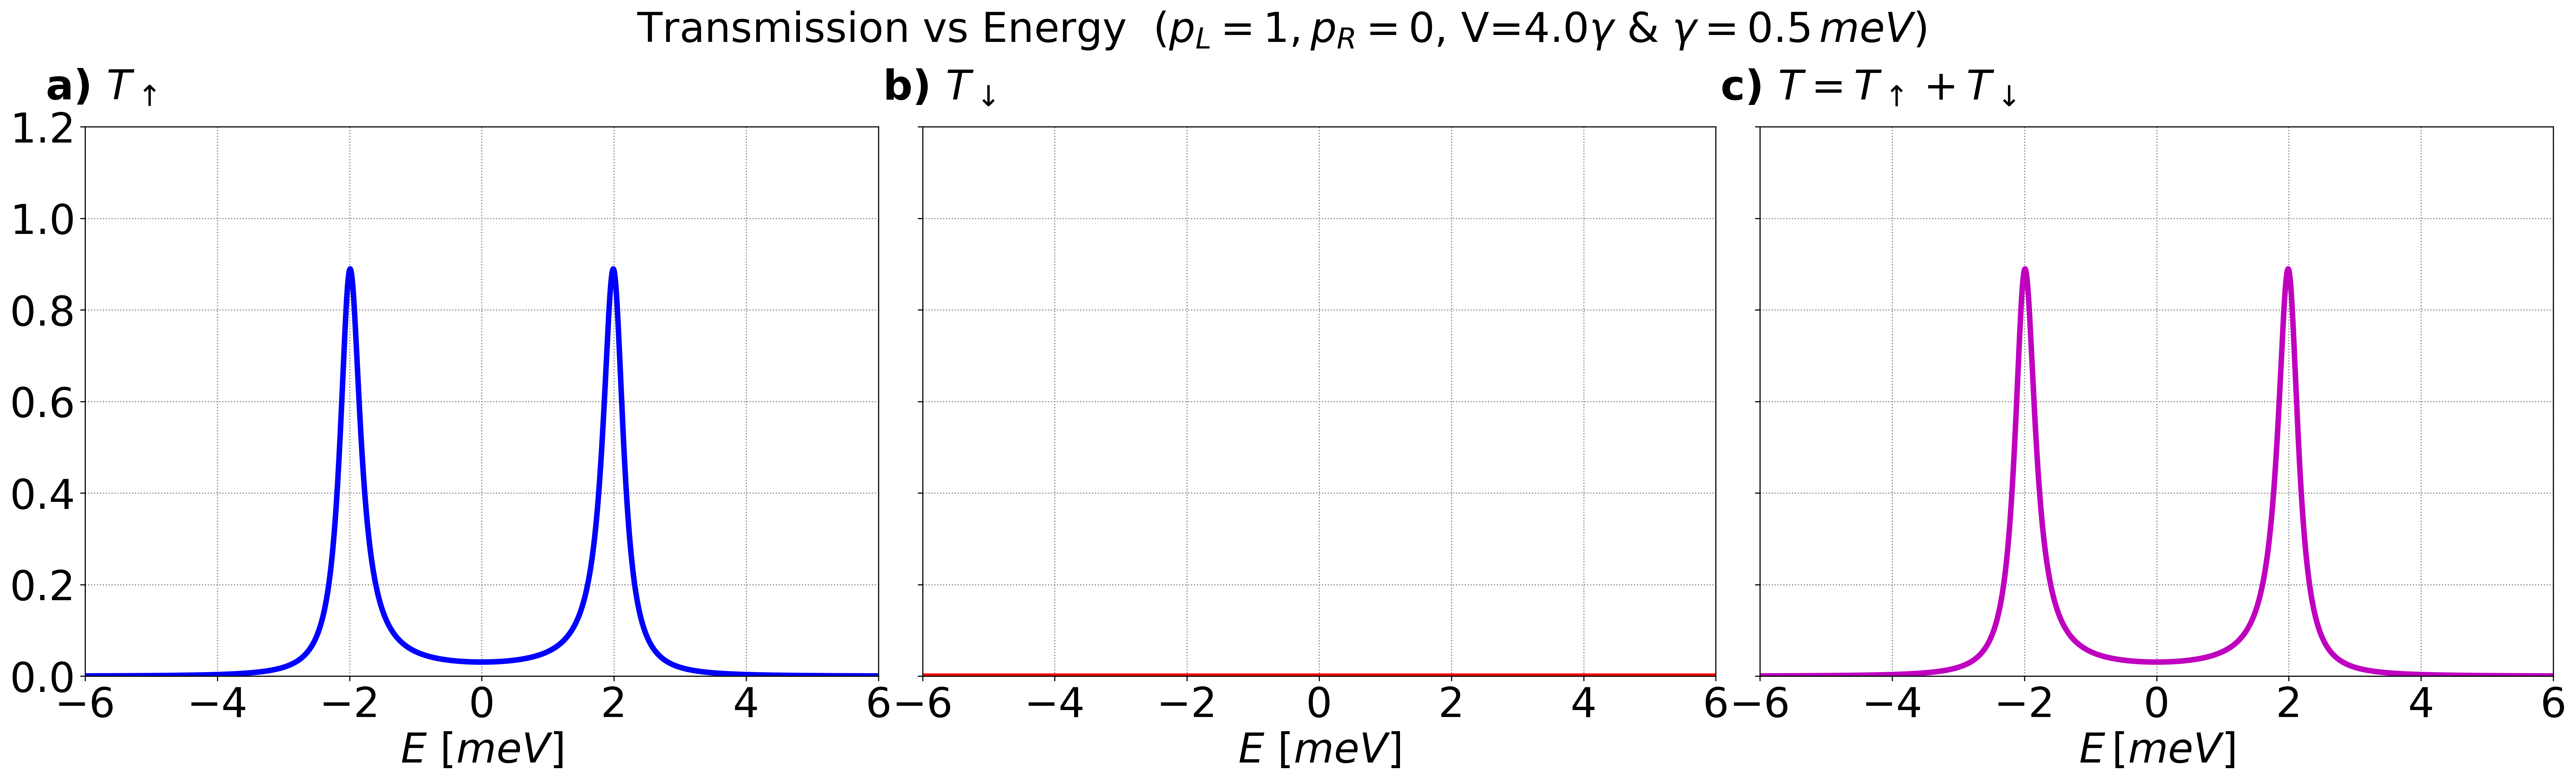

In [6]:
# do not forget constrained_layout=True to have some space between axes
fig = plt.figure(constrained_layout=True, figsize=(26,8), dpi=300)

# these are matplotlib.patch.Patch properties
props = dict(boxstyle='round', facecolor='wheat', alpha=0)

#Set the grid for the subplots
gs = GridSpec(1, 3, figure=fig)

#Add the subplots
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[0, 2])

#POLARIZATION = 0
# Transmission spin up Plot
p_L = 1
p_R = 0

ax1.grid(linestyle=':', color='grey')
#Define the \Delta parameter previously the definition of the Hamiltonian 

transmission_u=fy.Transmission(energy_axis,gamma, Hamiltonian, p_L,p_R)[0]
ax1.plot(energy_axis, transmission_u, "b", linestyle="-", lw=4)
ax1.set_xlabel(r'$E\,\,[meV]$',fontsize=30)
#ax1.set_ylabel(r'$T_{\uparrow}$',fontsize=30)
# Etiqueta a)
ax1.text(-0.05, 1.05, r'a) $T_{\uparrow}$', transform=ax1.transAxes, fontsize=30, fontweight='bold')
#ax1.axhline(y=8/9)
#####################################################################################################################
# Transmission DOWN Plot
ax2.grid(linestyle=':', color='grey')
transmission_d=fy.Transmission(energy_axis,gamma, Hamiltonian, p_L,p_R)[1]
ax2.plot(energy_axis, transmission_d, "r", linestyle="-", lw=4)
ax2.set_xlabel(r'$E\,\,[meV]$',fontsize=30)
#ax2.set_ylabel(r'$T_{\downarrow}$',fontsize=30)
# ax2.text(0.1, 0.85, r"$p_{L}\,=\,$"+str(p_L)+", "r"$p_{R}\,=\,$"+str(p_R), transform=ax2.transAxes, fontsize=16,
#         verticalalignment='top', bbox=props)
# Etiqueta b)
ax2.text(-0.05, 1.05, r'b) $T_{\downarrow}$', transform=ax2.transAxes, fontsize=30, fontweight='bold')

#########################################################################################################################
# Total Transmission Plot
ax3.grid(linestyle=':', color='grey')
ax3.plot(energy_axis, transmission_u + transmission_d, "m", linestyle="-", lw=4)
ax3.set_xlabel(r'$E\,[meV]$',fontsize=30)
#ax3.set_ylabel(r"$T=T_{\uparrow}+T_{\downarrow}$", fontsize=30)
# ax3.text(0.1, 0.85, r"$p_{L}\,=\,$"+str(p_L)+", "r"$p_{R}\,=\,$"+str(p_R), transform=ax3.transAxes, fontsize=16,
#         verticalalignment='top', bbox=props)
# Etiqueta c)
ax3.text(-0.05, 1.05, r'c) $T=T_{\uparrow}+T_{\downarrow}$', transform=ax3.transAxes, fontsize=30, fontweight='bold')

##########################################################################################################################
# Stablish limits for the subplots
ax1.set_ylim(0, 1.2)  
ax1.set_xlim(-6, 6)
ax2.set_ylim(0, 1.2)  
ax2.set_xlim(-6, 6)
ax3.set_ylim(0, 1.2)  
ax3.set_xlim(-6, 6)

# Set the fontsize for the x and y ticks
ax1.tick_params(axis='x', labelsize=30)
ax1.tick_params(axis='y', labelsize=30)
ax2.tick_params(axis='x', labelsize=30)
ax2.tick_params(axis='y', labelsize=30)
ax3.tick_params(axis='x', labelsize=30)
ax3.tick_params(axis='y', labelsize=30)

# Eliminar los números del eje x en el primer subplot
ax2.set_yticklabels([])
ax3.set_yticklabels([])

# Ajustar el diseño y mostrar los subplots
plt.suptitle("Transmission vs Energy "+r" ($p_{L}="+str(p_L)+r", p_{R}=$"+str(p_R)+r", V="+str(v/gamma)+r"$\gamma$ & $\gamma=$"+str(gamma)+r"$\,meV$)", fontsize=30)
plt.tight_layout()
plt.show()
fig.savefig('FM_NM_Transmission_reference.jpg')

In [7]:
# # do not forget constrained_layout=True to have some space between axes
# fig = plt.figure(constrained_layout=True, figsize=(26,8), dpi=300)

# # these are matplotlib.patch.Patch properties
# props = dict(boxstyle='round', facecolor='wheat', alpha=0)

# #Set the grid for the subplots
# gs = GridSpec(1, 3, figure=fig)

# #Add the subplots
# ax1 = fig.add_subplot(gs[0, 0])
# ax2 = fig.add_subplot(gs[0, 1])
# ax3 = fig.add_subplot(gs[0, 2])

# #POLARIZATIONS 
# p_L1 = 0
# p_R1 = 0
# transmission_u1=fy.Transmission(energy_axis,gamma, Hamiltonian, p_L1,p_R1)[0]
# transmission_d1=fy.Transmission(energy_axis,gamma, Hamiltonian, p_L1,p_R1)[1]
# total_transmission1= transmission_u1 + transmission_d1

# p_L2 = 0.5
# p_R2 = 0.5
# transmission_u2=fy.Transmission(energy_axis,gamma, Hamiltonian, p_L2,p_R2)[0]
# transmission_d2=fy.Transmission(energy_axis,gamma, Hamiltonian, p_L2,p_R2)[1]
# total_transmission2= transmission_u2 + transmission_d2

# p_L3 = 1
# p_R3 = 1
# transmission_u3=fy.Transmission(energy_axis,gamma, Hamiltonian, p_L3,p_R3)[0]
# transmission_d3=fy.Transmission(energy_axis,gamma, Hamiltonian, p_L3,p_R3)[1]
# total_transmission3= transmission_u3 + transmission_d3

# p_L4 = 0.5
# p_R4 = -0.5
# transmission_u4=fy.Transmission(energy_axis,gamma, Hamiltonian, p_L4,p_R4)[0]
# transmission_d4=fy.Transmission(energy_axis,gamma, Hamiltonian, p_L4,p_R4)[1]
# total_transmission4= transmission_u4 + transmission_d4

# p_L5 = 1
# p_R5 = -1
# transmission_u5=fy.Transmission(energy_axis,gamma, Hamiltonian, p_L5,p_R5)[0]
# transmission_d5=fy.Transmission(energy_axis,gamma, Hamiltonian, p_L5,p_R5)[1]
# total_transmission5= transmission_u5 + transmission_d5


# # Transmission spin up Plot

# ax1.grid(linestyle=':', color='grey')
# #Define the \Delta parameter previously the definition of the Hamiltonian 


# ax1.plot(energy_axis, transmission_u1, linestyle=":", lw=6, label=r"$p_{L}=$"+str(p_L1)+r", $p_{R}=$"+str(p_R1))
# ax1.plot(energy_axis, transmission_u2, linestyle="-", lw=4, label=r"$p_{L}=$"+str(p_L2)+r", $p_{R}=$"+str(p_R2))
# ax1.plot(energy_axis, transmission_u3, linestyle="-", lw=4, label=r"$p_{L}=$"+str(p_L3)+r", $p_{R}=$"+str(p_R3))
# ax1.plot(energy_axis, transmission_u4, linestyle="-", lw=4, label=r"$p_{L}=$"+str(p_L4)+r", $p_{R}=$"+str(p_R4))
# ax1.plot(energy_axis, transmission_u5, linestyle="-", lw=4, label=r"$p_{L}=$"+str(p_L5)+r", $p_{R}=$"+str(p_R5))
# ax1.set_xlabel(r'$E\,\,[meV]$',fontsize=30)
# #ax1.set_ylabel(r'$T_{\uparrow}$',fontsize=30)
# # Etiqueta a)
# ax1.text(-0.05, 1.05, r'a) $T_{\uparrow}$', transform=ax1.transAxes, fontsize=30, fontweight='bold')
# ax1.legend(
#     fontsize=20,
#     title="Polarization: ",
#     title_fontsize=20
# )

# #####################################################################################################################
# # Transmission DOWN Plot
# ax2.grid(linestyle=':', color='grey')

# ax2.plot(energy_axis, transmission_d1, linestyle="-", lw=4, label=r"$p_{L}=$"+str(p_L1)+r", $p_{R}=$"+str(p_R1))
# ax2.plot(energy_axis, transmission_d2, linestyle="-", lw=4, label=r"$p_{L}=$"+str(p_L2)+r", $p_{R}=$"+str(p_R2))
# ax2.plot(energy_axis, transmission_d3, linestyle="-", lw=4, label=r"$p_{L}=$"+str(p_L3)+r", $p_{R}=$"+str(p_R3))
# ax2.plot(energy_axis, transmission_d4, linestyle="-", lw=4, label=r"$p_{L}=$"+str(p_L4)+r", $p_{R}=$"+str(p_R4))
# ax2.plot(energy_axis, transmission_d5, linestyle="-", lw=4, label=r"$p_{L}=$"+str(p_L5)+r", $p_{R}=$"+str(p_R5))
# ax2.set_xlabel(r'$E\,\,[meV]$',fontsize=30)
# #ax2.set_ylabel(r'$T_{\downarrow}$',fontsize=30)
# # ax2.text(0.1, 0.85, r"$p_{L}\,=\,$"+str(p_L)+", "r"$p_{R}\,=\,$"+str(p_R), transform=ax2.transAxes, fontsize=16,
# #         verticalalignment='top', bbox=props)
# # Etiqueta b)
# ax2.text(-0.05, 1.05, r'b) $T_{\downarrow}$', transform=ax2.transAxes, fontsize=30, fontweight='bold')
# ax2.legend(
#     fontsize=20,
#     title="Polarization: ",
#     title_fontsize=20
# )

# #########################################################################################################################
# # Total Transmission Plot
# ax3.grid(linestyle=':', color='grey')
# ax3.plot(energy_axis, total_transmission1, linestyle="-", lw=4, label=r"$p_{L}=$"+str(p_L1)+r", $p_{R}=$"+str(p_R1))
# ax3.plot(energy_axis, total_transmission2, linestyle="-", lw=4, label=r"$p_{L}=$"+str(p_L2)+r", $p_{R}=$"+str(p_R2))
# ax3.plot(energy_axis, total_transmission3, linestyle="-", lw=4, label=r"$p_{L}=$"+str(p_L3)+r", $p_{R}=$"+str(p_R3))
# ax3.plot(energy_axis, total_transmission4, linestyle="-", lw=4, label=r"$p_{L}=$"+str(p_L4)+r", $p_{R}=$"+str(p_R4))
# ax3.plot(energy_axis, total_transmission5, linestyle="-", lw=4, label=r"$p_{L}=$"+str(p_L5)+r", $p_{R}=$"+str(p_R5))
# ax3.set_xlabel(r'$E\,[meV]$',fontsize=30)
# #ax3.set_ylabel(r"$T=T_{\uparrow}+T_{\downarrow}$", fontsize=30)
# # ax3.text(0.1, 0.85, r"$p_{L}\,=\,$"+str(p_L)+", "r"$p_{R}\,=\,$"+str(p_R), transform=ax3.transAxes, fontsize=16,
# #         verticalalignment='top', bbox=props)
# # Etiqueta c)
# ax3.text(-0.05, 1.05, r'c) $T=T_{\uparrow}+T_{\downarrow}$', transform=ax3.transAxes, fontsize=30, fontweight='bold')
# ax3.legend(
#     fontsize=20,
#     title="Polarization: ",
#     title_fontsize=20
# )

# ##########################################################################################################################
# # Stablish limits for the subplots
# ax1.set_ylim(0, 2.5)  
# ax1.set_xlim(-6, 6)
# ax2.set_ylim(0, 2.5)  
# ax2.set_xlim(-6, 6)
# ax3.set_ylim(0, 2.5)  
# ax3.set_xlim(-6, 6)

# # Set the fontsize for the x and y ticks
# ax1.tick_params(axis='x', labelsize=30)
# ax1.tick_params(axis='y', labelsize=30)
# ax2.tick_params(axis='x', labelsize=30)
# ax2.tick_params(axis='y', labelsize=30)
# ax3.tick_params(axis='x', labelsize=30)
# ax3.tick_params(axis='y', labelsize=30)

# # Eliminar los números del eje x en el primer subplot
# ax2.set_yticklabels([])
# ax3.set_yticklabels([])

# # Ajustar el diseño y mostrar los subplots
# plt.suptitle("Transmission vs Energy "+r" ($p_{L}="+str(p_L)+r", p_{R}=$"+str(p_R)+r", V="+str(v/gamma)+r"$\gamma$ & $\gamma=$"+str(gamma)+r"$\,meV$)", fontsize=30)
# plt.tight_layout()
# plt.show()
# #fig.savefig('polarized_leads_Transmission_reference.jpg')

/home/franklin/miniconda3/envs/py37/lib/python3.7/site-packages/ipykernel_launcher.py:146: UserWarning: This figure was using constrained_layout, but that is incompatible with subplots_adjust and/or tight_layout; disabling constrained_layout.


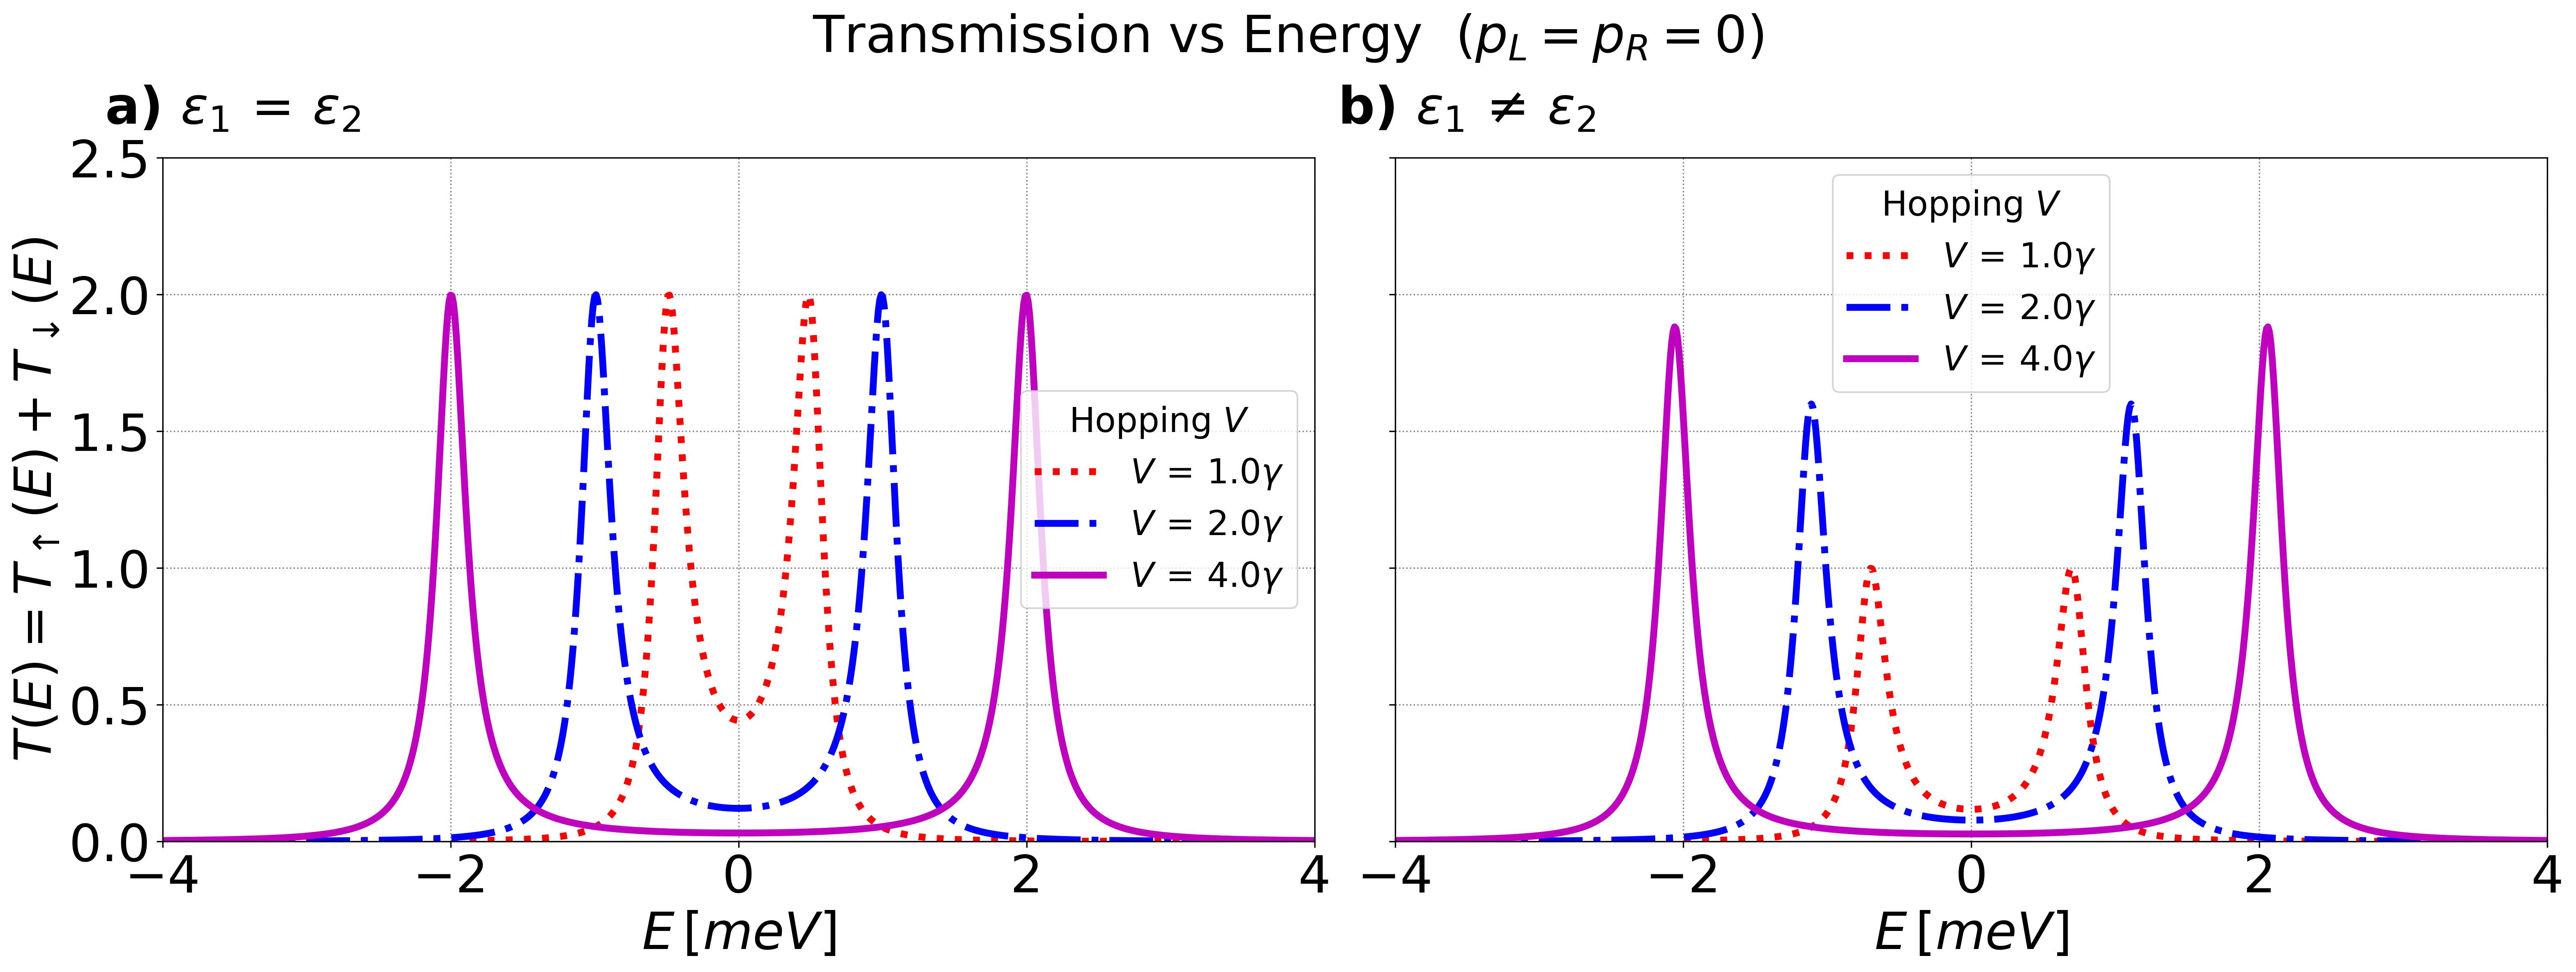

In [8]:
# do not forget constrained_layout=True to have some space between axes
fig = plt.figure(constrained_layout=True, figsize=(21, 8), dpi=300)

# these are matplotlib.patch.Patch properties
props = dict(boxstyle='round', facecolor='wheat', alpha=0)

#Set the grid for the subplots
gs = GridSpec(1, 2, figure=fig)

#Add the subplots
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])

#POLARIZATION = 0
# Transmission spin up Plot
p=0

#Site energies:
e_1 = 0 #meV
e_2 = 0 #meV

ax1.grid(linestyle=':', color='grey')
################################################################################################################
delta=0

e_1_u = e_1 + delta #meV
e_1_d = e_1 - delta #meV
e_2_u = e_2 + delta #meV
e_2_d = e_2 - delta #meV
v = 1*gamma 

Hamiltonian = np.array([[e_1_u, 0 , v , 0],[0, e_1_d, 0, v], [v, 0, e_2_u, 0], [0, v, 0, e_2_d]], dtype = complex)

ax1.plot(energy_axis, fy.Transmission(energy_axis, gamma, Hamiltonian, p, p)[0]\
     +fy.Transmission(energy_axis, gamma, Hamiltonian, p, p)[1], "r", label=r"$V\,=\,$"+str(v/gamma)+r"$\gamma$", linestyle=":", lw=4)

##################################################################################################################
e_1_u = e_1 + delta #meV
e_1_d = e_1 - delta #meV
e_2_u = e_2 + delta #meV
e_2_d = e_2 - delta #meV
v = 2*gamma 

Hamiltonian = np.array([[e_1_u, 0 , v , 0],[0, e_1_d, 0, v], [v, 0, e_2_u, 0], [0, v, 0, e_2_d]], dtype = complex)

ax1.plot(energy_axis, fy.Transmission(energy_axis, gamma, Hamiltonian, p, p)[0]\
     +fy.Transmission(energy_axis, gamma, Hamiltonian, p, p)[1], "b", label=r"$V\,=\,$"+str(v/gamma)+r"$\gamma$", linestyle="-.", lw=4)

#####################################################################################################################
e_1_u = e_1 + delta #meV
e_1_d = e_1 - delta #meV
e_2_u = e_2 + delta #meV
e_2_d = e_2 - delta #meV
v = 4*gamma 

Hamiltonian = np.array([[e_1_u, 0 , v , 0],[0, e_1_d, 0, v], [v, 0, e_2_u, 0], [0, v, 0, e_2_d]], dtype = complex)


ax1.plot(energy_axis, fy.Transmission(energy_axis, gamma, Hamiltonian, p, p)[0]\
     +fy.Transmission(energy_axis, gamma, Hamiltonian, p, p)[1], "m", label=r"$V\,=\,$"+str(v/gamma)+r"$\gamma$", linestyle="-", lw=4)


##################################################################################################################
ax1.set_xlabel(r'$E\,[meV]$',fontsize=30)
ax1.set_ylabel(r'$T(E) = T_{\uparrow}(E)+T_{\downarrow}(E)$',fontsize=30)
ax1.legend(
    fontsize=20,
    title="Hopping "+r"$V$",
    title_fontsize=20
)
#ax1.axhline(1.99)
# Etiqueta a)
ax1.text(-0.05, 1.05, r'a) $\epsilon_{1}\,=\,\epsilon_{2}$', transform=ax1.transAxes, fontsize=30, fontweight='bold')

#Site energies:
e_1 = -0.5 #meV
e_2 = 0.5 #meV

ax2.grid(linestyle=':', color='grey')
################################################################################################################
delta=0
e_1_u = e_1 + delta #meV
e_1_d = e_1 - delta #meV
e_2_u = e_2 + delta #meV
e_2_d = e_2 - delta #meV
v = 1*gamma 

Hamiltonian = np.array([[e_1_u, 0 , v , 0],[0, e_1_d, 0, v], [v, 0, e_2_u, 0], [0, v, 0, e_2_d]], dtype = complex)

ax2.plot(energy_axis, fy.Transmission(energy_axis, gamma, Hamiltonian, p, p)[0]\
     +fy.Transmission(energy_axis, gamma, Hamiltonian, p, p)[1], "r", label=r"$V\,=\,$"+str(v/gamma)+r"$\gamma$", linestyle=":", lw=4)

##################################################################################################################
e_1_u = e_1 + delta #meV
e_1_d = e_1 - delta #meV
e_2_u = e_2 + delta #meV
e_2_d = e_2 - delta #meV
v = 2*gamma 

Hamiltonian = np.array([[e_1_u, 0 , v , 0],[0, e_1_d, 0, v], [v, 0, e_2_u, 0], [0, v, 0, e_2_d]], dtype = complex)

ax2.plot(energy_axis, fy.Transmission(energy_axis, gamma, Hamiltonian, p, p)[0]\
     +fy.Transmission(energy_axis, gamma, Hamiltonian, p, p)[1], "b", label=r"$V\,=\,$"+str(v/gamma)+r"$\gamma$", linestyle="-.", lw=4)

#####################################################################################################################

e_1_u = e_1 + delta #meV
e_1_d = e_1 - delta #meV
e_2_u = e_2 + delta #meV
e_2_d = e_2 - delta #meV
v = 4*gamma 

Hamiltonian = np.array([[e_1_u, 0 , v , 0],[0, e_1_d, 0, v], [v, 0, e_2_u, 0], [0, v, 0, e_2_d]], dtype = complex)

ax2.plot(energy_axis, fy.Transmission(energy_axis, gamma, Hamiltonian, p, p)[0]\
     +fy.Transmission(energy_axis, gamma, Hamiltonian, p, p)[1], "m", label=r"$V\,=\,$"+str(v/gamma)+r"$\gamma$", linestyle="-", lw=4)
##################################################################################################################
ax2.set_xlabel(r'$E\,[meV]$',fontsize=30)
#ax2.set_ylabel(r'$T(E) = T_{\uparrow}(E)+T_{\downarrow}(E)$',fontsize=20)
ax2.legend(
    fontsize=20,
    title="Hopping "+r"$V$",
    title_fontsize=20
)

# Etiqueta b)
ax2.text(-0.05, 1.05, r'b) $\epsilon_{1}\,\neq\,\epsilon_{2}$', transform=ax2.transAxes, fontsize=30, fontweight='bold')

# Stablish limits for the subplots
ax1.set_ylim(0, 2.5)  
ax1.set_xlim(-4, 4)  
ax2.set_ylim(0, 2.5)  
ax2.set_xlim(-4, 4)

# Set the fontsize for the x and y ticks
ax1.tick_params(axis='x', labelsize=30)
ax1.tick_params(axis='y', labelsize=30)
ax2.tick_params(axis='x', labelsize=30)
ax2.tick_params(axis='y', labelsize=30)

# Eliminar los números del eje y en el primer subplot
ax2.set_yticklabels([])

# Ajustar el diseño y mostrar los subplots
plt.suptitle("Transmission vs Energy "+r" ($p_{L}=p_{R}=$"+str(p)+")", fontsize=30)
plt.tight_layout()
plt.show()
fig.savefig('horizontal_Transmission_reference.jpg')


/home/franklin/miniconda3/envs/py37/lib/python3.7/site-packages/ipykernel_launcher.py:146: UserWarning: This figure was using constrained_layout, but that is incompatible with subplots_adjust and/or tight_layout; disabling constrained_layout.


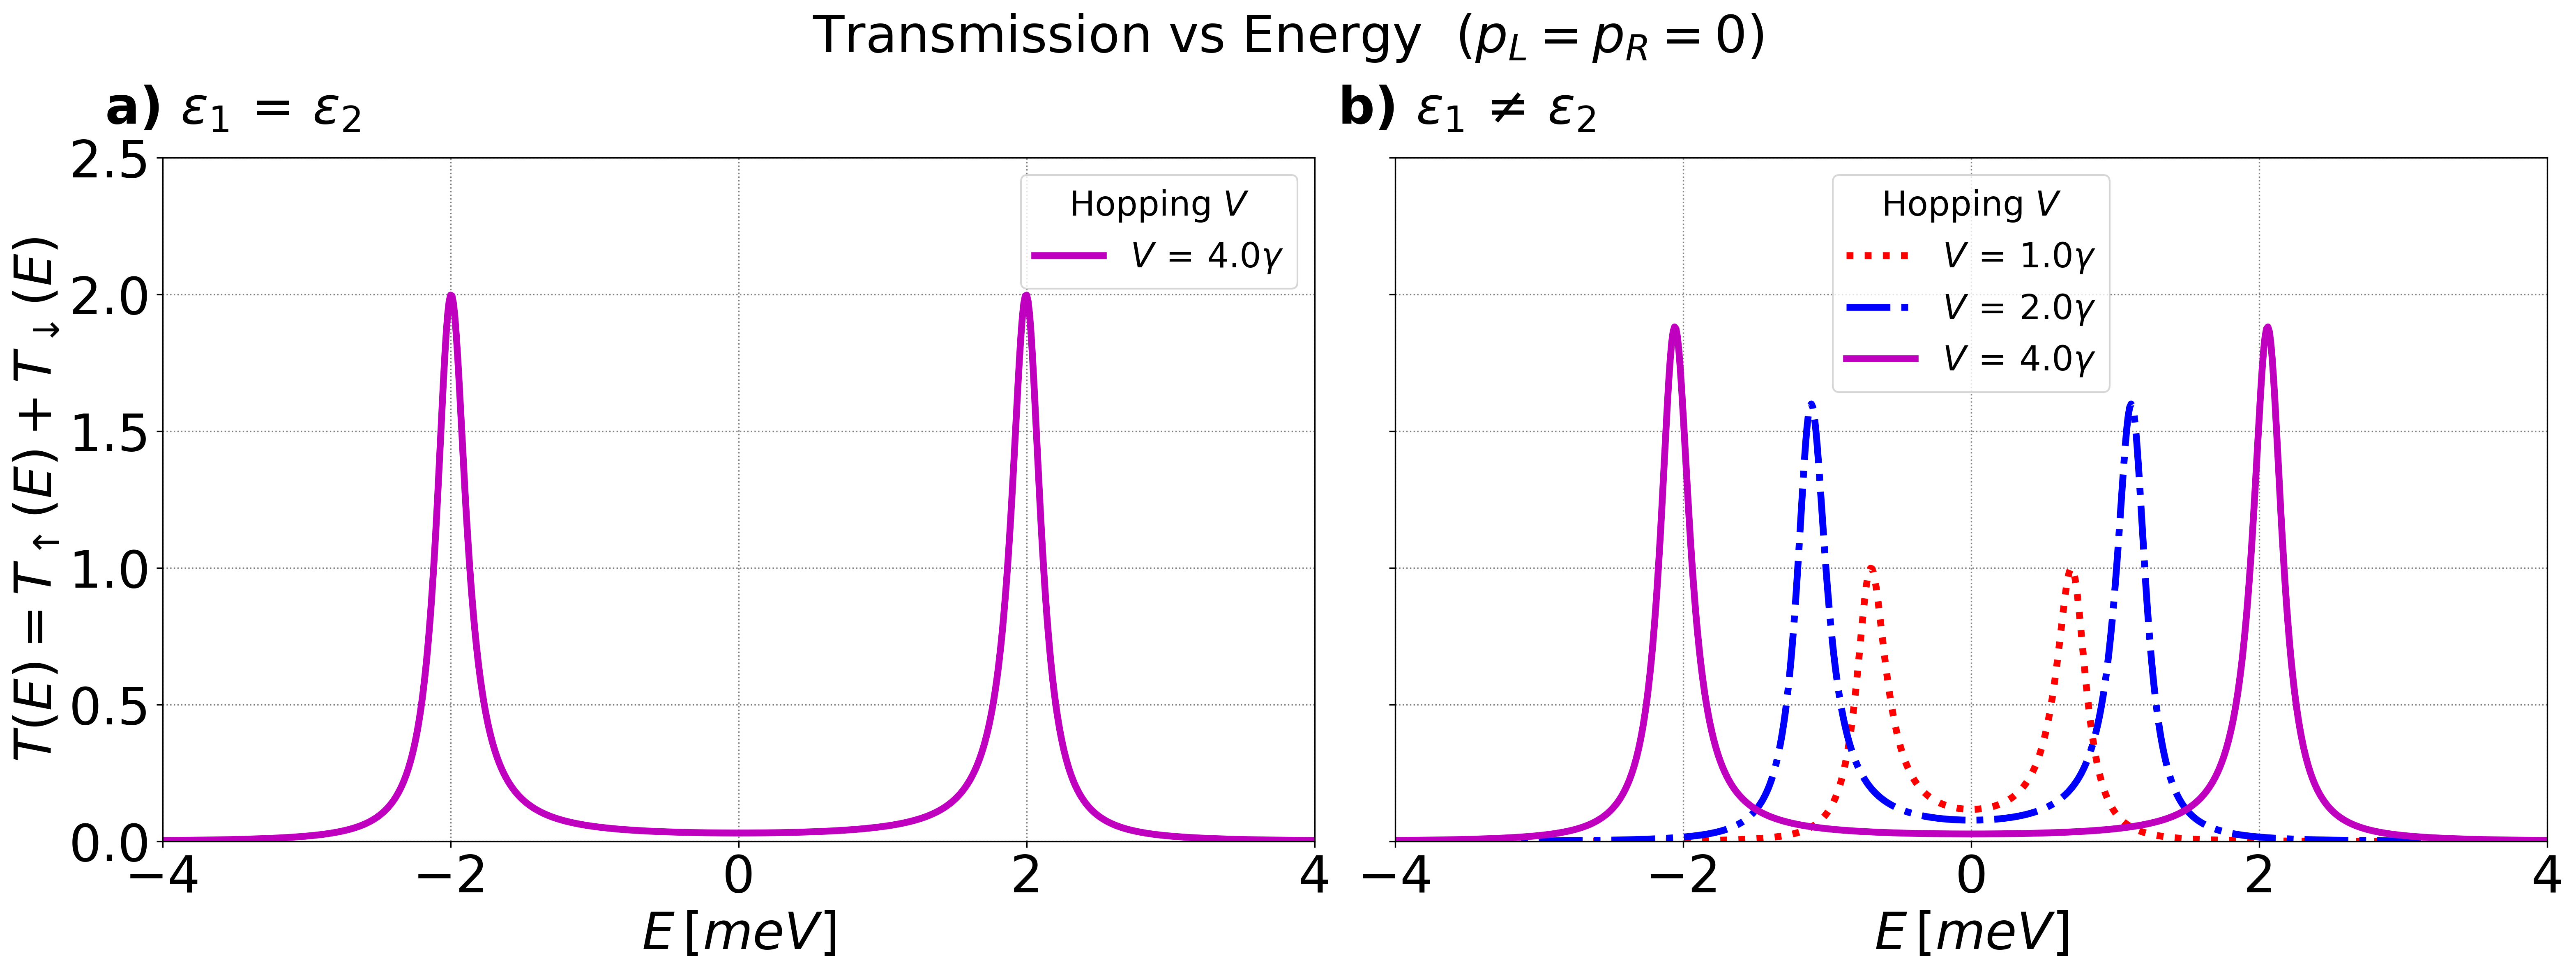

In [9]:
# do not forget constrained_layout=True to have some space between axes
fig = plt.figure(constrained_layout=True, figsize=(21, 8), dpi=300)

# these are matplotlib.patch.Patch properties
props = dict(boxstyle='round', facecolor='wheat', alpha=0)

#Set the grid for the subplots
gs = GridSpec(1, 2, figure=fig)

#Add the subplots
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])

#POLARIZATION = 0
# Transmission spin up Plot
p=0

#Site energies:
e_1 = 0 #meV
e_2 = 0 #meV

ax1.grid(linestyle=':', color='grey')
################################################################################################################
delta=0

e_1_u = e_1 + delta #meV
e_1_d = e_1 - delta #meV
e_2_u = e_2 + delta #meV
e_2_d = e_2 - delta #meV
v = 1*gamma 

Hamiltonian = np.array([[e_1_u, 0 , v , 0],[0, e_1_d, 0, v], [v, 0, e_2_u, 0], [0, v, 0, e_2_d]], dtype = complex)

#ax1.plot(energy_axis, fy.Transmission(energy_axis, gamma, Hamiltonian, p, p)[0]\
#     +fy.Transmission(energy_axis, gamma, Hamiltonian, p, p)[1], "r", label=r"$V\,=\,$"+str(v/gamma)+r"$\gamma$", linestyle=":", lw=4)

##################################################################################################################
e_1_u = e_1 + delta #meV
e_1_d = e_1 - delta #meV
e_2_u = e_2 + delta #meV
e_2_d = e_2 - delta #meV
v = 2*gamma 

Hamiltonian = np.array([[e_1_u, 0 , v , 0],[0, e_1_d, 0, v], [v, 0, e_2_u, 0], [0, v, 0, e_2_d]], dtype = complex)

#ax1.plot(energy_axis, fy.Transmission(energy_axis, gamma, Hamiltonian, p, p)[0]\
#     +fy.Transmission(energy_axis, gamma, Hamiltonian, p, p)[1], "b", label=r"$V\,=\,$"+str(v/gamma)+r"$\gamma$", linestyle="-.", lw=4)

#####################################################################################################################
e_1_u = e_1 + delta #meV
e_1_d = e_1 - delta #meV
e_2_u = e_2 + delta #meV
e_2_d = e_2 - delta #meV
v = 4*gamma 

Hamiltonian = np.array([[e_1_u, 0 , v , 0],[0, e_1_d, 0, v], [v, 0, e_2_u, 0], [0, v, 0, e_2_d]], dtype = complex)


ax1.plot(energy_axis, fy.Transmission(energy_axis, gamma, Hamiltonian, p, p)[0]\
     +fy.Transmission(energy_axis, gamma, Hamiltonian, p, p)[1], "m", label=r"$V\,=\,$"+str(v/gamma)+r"$\gamma$", linestyle="-", lw=4)


##################################################################################################################
ax1.set_xlabel(r'$E\,[meV]$',fontsize=30)
ax1.set_ylabel(r'$T(E) = T_{\uparrow}(E)+T_{\downarrow}(E)$',fontsize=30)
ax1.legend(
    fontsize=20,
    title="Hopping "+r"$V$",
    title_fontsize=20
)
#ax1.axhline(1.99)
# Etiqueta a)
ax1.text(-0.05, 1.05, r'a) $\epsilon_{1}\,=\,\epsilon_{2}$', transform=ax1.transAxes, fontsize=30, fontweight='bold')

#Site energies:
e_1 = -0.5 #meV
e_2 = 0.5 #meV

ax2.grid(linestyle=':', color='grey')
################################################################################################################
delta=0
e_1_u = e_1 + delta #meV
e_1_d = e_1 - delta #meV
e_2_u = e_2 + delta #meV
e_2_d = e_2 - delta #meV
v = 1*gamma 

Hamiltonian = np.array([[e_1_u, 0 , v , 0],[0, e_1_d, 0, v], [v, 0, e_2_u, 0], [0, v, 0, e_2_d]], dtype = complex)

ax2.plot(energy_axis, fy.Transmission(energy_axis, gamma, Hamiltonian, p, p)[0]\
     +fy.Transmission(energy_axis, gamma, Hamiltonian, p, p)[1], "r", label=r"$V\,=\,$"+str(v/gamma)+r"$\gamma$", linestyle=":", lw=4)

##################################################################################################################
e_1_u = e_1 + delta #meV
e_1_d = e_1 - delta #meV
e_2_u = e_2 + delta #meV
e_2_d = e_2 - delta #meV
v = 2*gamma 

Hamiltonian = np.array([[e_1_u, 0 , v , 0],[0, e_1_d, 0, v], [v, 0, e_2_u, 0], [0, v, 0, e_2_d]], dtype = complex)

ax2.plot(energy_axis, fy.Transmission(energy_axis, gamma, Hamiltonian, p, p)[0]\
     +fy.Transmission(energy_axis, gamma, Hamiltonian, p, p)[1], "b", label=r"$V\,=\,$"+str(v/gamma)+r"$\gamma$", linestyle="-.", lw=4)

#####################################################################################################################

e_1_u = e_1 + delta #meV
e_1_d = e_1 - delta #meV
e_2_u = e_2 + delta #meV
e_2_d = e_2 - delta #meV
v = 4*gamma 

Hamiltonian = np.array([[e_1_u, 0 , v , 0],[0, e_1_d, 0, v], [v, 0, e_2_u, 0], [0, v, 0, e_2_d]], dtype = complex)

ax2.plot(energy_axis, fy.Transmission(energy_axis, gamma, Hamiltonian, p, p)[0]\
     +fy.Transmission(energy_axis, gamma, Hamiltonian, p, p)[1], "m", label=r"$V\,=\,$"+str(v/gamma)+r"$\gamma$", linestyle="-", lw=4)
##################################################################################################################
ax2.set_xlabel(r'$E\,[meV]$',fontsize=30)
#ax2.set_ylabel(r'$T(E) = T_{\uparrow}(E)+T_{\downarrow}(E)$',fontsize=20)
ax2.legend(
    fontsize=20,
    title="Hopping "+r"$V$",
    title_fontsize=20
)

# Etiqueta b)
ax2.text(-0.05, 1.05, r'b) $\epsilon_{1}\,\neq\,\epsilon_{2}$', transform=ax2.transAxes, fontsize=30, fontweight='bold')

# Stablish limits for the subplots
ax1.set_ylim(0, 2.5)  
ax1.set_xlim(-4, 4)  
ax2.set_ylim(0, 2.5)  
ax2.set_xlim(-4, 4)

# Set the fontsize for the x and y ticks
ax1.tick_params(axis='x', labelsize=30)
ax1.tick_params(axis='y', labelsize=30)
ax2.tick_params(axis='x', labelsize=30)
ax2.tick_params(axis='y', labelsize=30)

# Eliminar los números del eje y en el primer subplot
ax2.set_yticklabels([])

# Ajustar el diseño y mostrar los subplots
plt.suptitle("Transmission vs Energy "+r" ($p_{L}=p_{R}=$"+str(p)+")", fontsize=30)
plt.tight_layout()
plt.show()
fig.savefig('horizontal_Transmission_reference_presentation.jpg')


/home/franklin/miniconda3/envs/py37/lib/python3.7/site-packages/ipykernel_launcher.py:173: UserWarning: This figure was using constrained_layout, but that is incompatible with subplots_adjust and/or tight_layout; disabling constrained_layout.


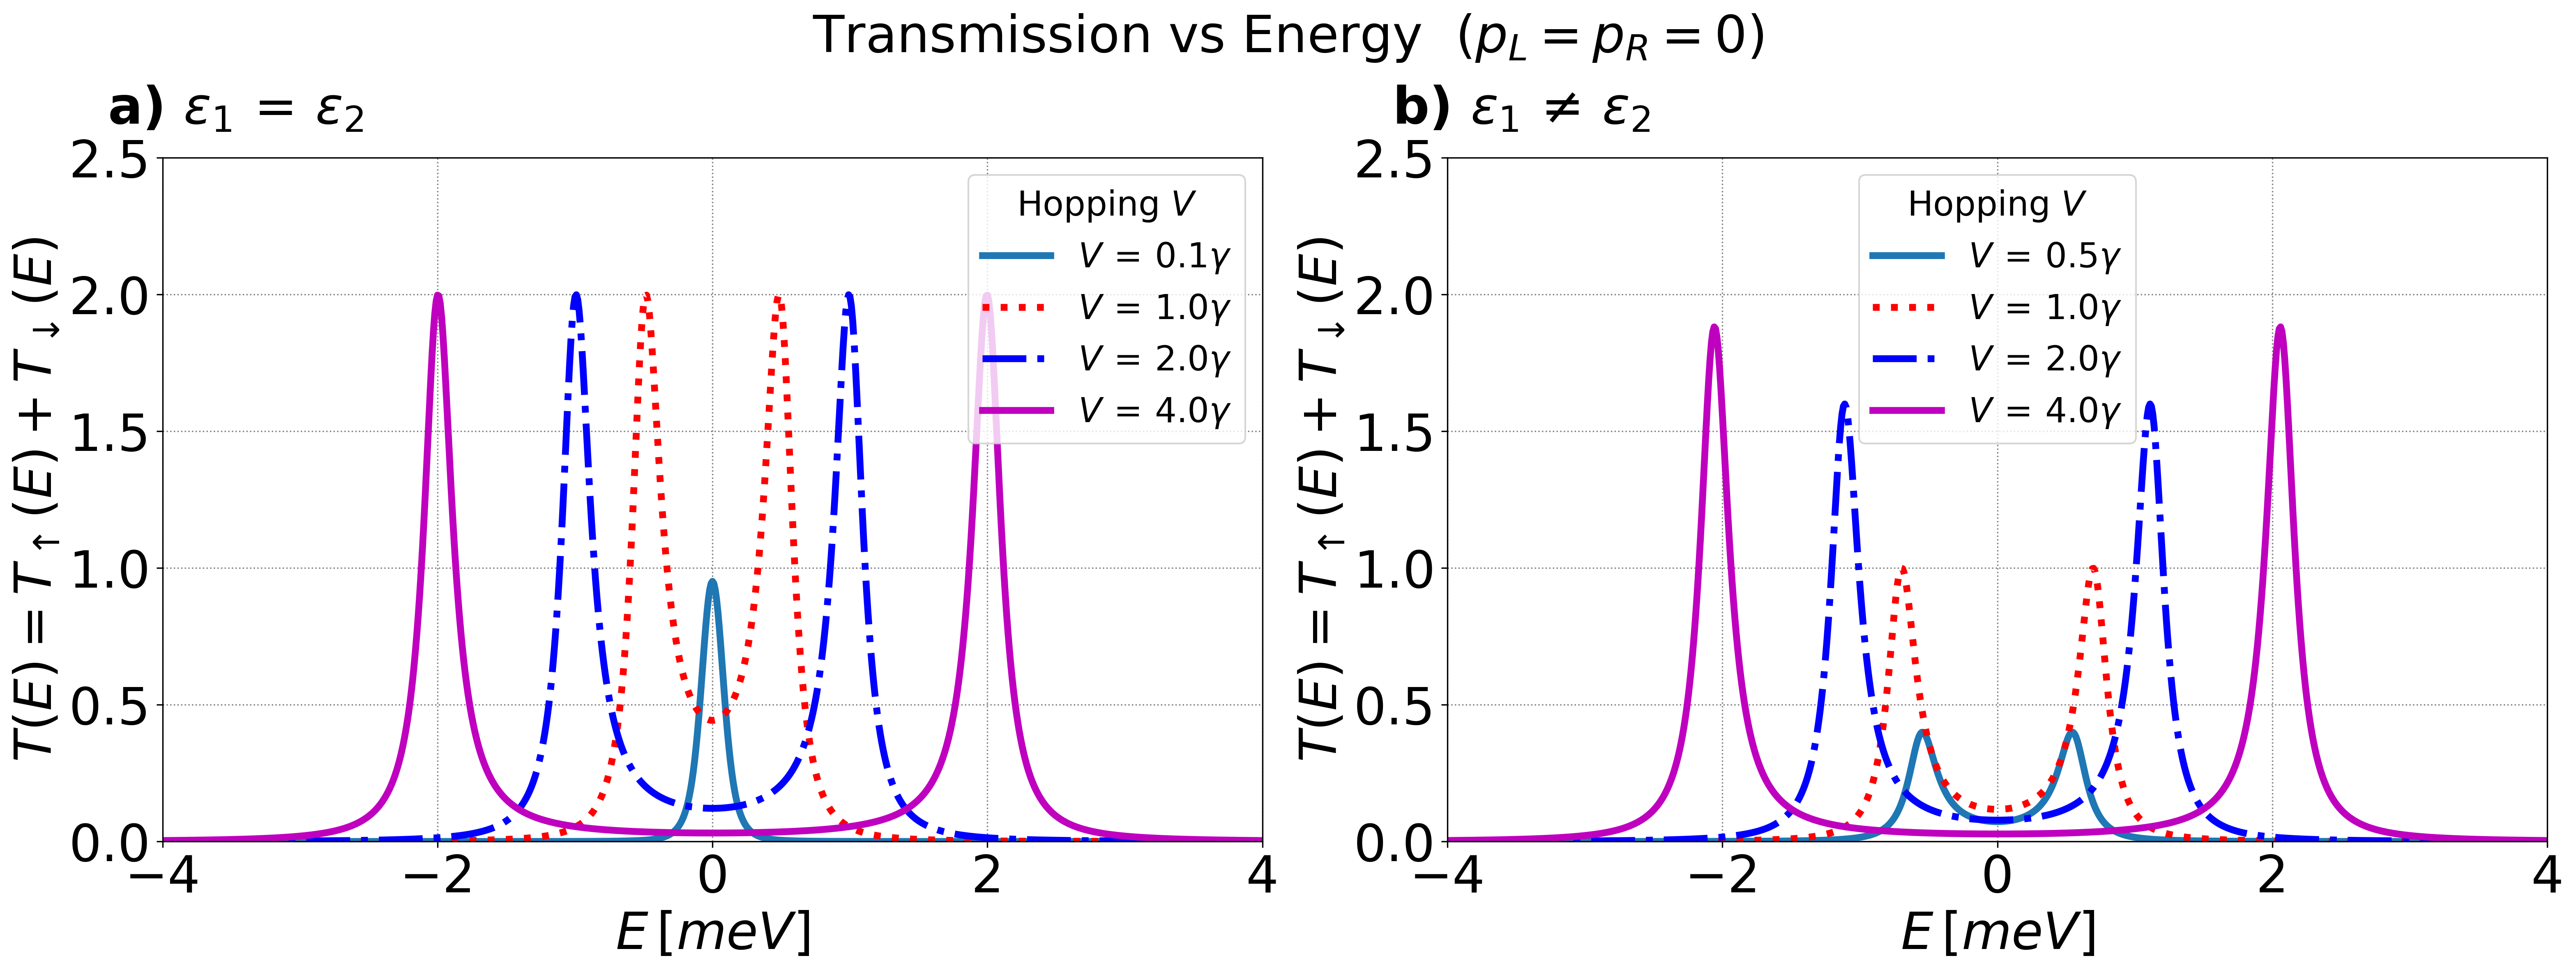

In [10]:
# do not forget constrained_layout=True to have some space between axes
fig = plt.figure(constrained_layout=True, figsize=(21, 8), dpi=300)

# these are matplotlib.patch.Patch properties
props = dict(boxstyle='round', facecolor='wheat', alpha=0)

#Set the grid for the subplots
gs = GridSpec(1, 2, figure=fig)

#Add the subplots
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])

#POLARIZATION = 0
# Transmission spin up Plot
p=0

#Site energies:
e_1 = 0 #meV
e_2 = 0 #meV

ax1.grid(linestyle=':', color='grey')
################################################################################################################
delta=0

e_1_u = e_1 + delta #meV
e_1_d = e_1 - delta #meV
e_2_u = e_2 + delta #meV
e_2_d = e_2 - delta #meV
v = 0.1*gamma 

Hamiltonian = np.array([[e_1_u, 0 , v , 0],[0, e_1_d, 0, v], [v, 0, e_2_u, 0], [0, v, 0, e_2_d]], dtype = complex)

ax1.plot(energy_axis, fy.Transmission(energy_axis, gamma, Hamiltonian, p, p)[0]\
     +fy.Transmission(energy_axis, gamma, Hamiltonian, p, p)[1], label=r"$V\,=\,$"+str(v/gamma)+r"$\gamma$", linestyle="-", lw=4)


#################################################################################################################
e_1_u = e_1 + delta #meV
e_1_d = e_1 - delta #meV
e_2_u = e_2 + delta #meV
e_2_d = e_2 - delta #meV
v = 1*gamma 

Hamiltonian = np.array([[e_1_u, 0 , v , 0],[0, e_1_d, 0, v], [v, 0, e_2_u, 0], [0, v, 0, e_2_d]], dtype = complex)

ax1.plot(energy_axis, fy.Transmission(energy_axis, gamma, Hamiltonian, p, p)[0]\
     +fy.Transmission(energy_axis, gamma, Hamiltonian, p, p)[1], "r", label=r"$V\,=\,$"+str(v/gamma)+r"$\gamma$", linestyle=":", lw=4)

##################################################################################################################
e_1_u = e_1 + delta #meV
e_1_d = e_1 - delta #meV
e_2_u = e_2 + delta #meV
e_2_d = e_2 - delta #meV
v = 2*gamma 

Hamiltonian = np.array([[e_1_u, 0 , v , 0],[0, e_1_d, 0, v], [v, 0, e_2_u, 0], [0, v, 0, e_2_d]], dtype = complex)

ax1.plot(energy_axis, fy.Transmission(energy_axis, gamma, Hamiltonian, p, p)[0]\
     +fy.Transmission(energy_axis, gamma, Hamiltonian, p, p)[1], "b", label=r"$V\,=\,$"+str(v/gamma)+r"$\gamma$", linestyle="-.", lw=4)

#####################################################################################################################
e_1_u = e_1 + delta #meV
e_1_d = e_1 - delta #meV
e_2_u = e_2 + delta #meV
e_2_d = e_2 - delta #meV
v = 4*gamma 

Hamiltonian = np.array([[e_1_u, 0 , v , 0],[0, e_1_d, 0, v], [v, 0, e_2_u, 0], [0, v, 0, e_2_d]], dtype = complex)


ax1.plot(energy_axis, fy.Transmission(energy_axis, gamma, Hamiltonian, p, p)[0]\
     +fy.Transmission(energy_axis, gamma, Hamiltonian, p, p)[1], "m", label=r"$V\,=\,$"+str(v/gamma)+r"$\gamma$", linestyle="-", lw=4)


##################################################################################################################
ax1.set_xlabel(r'$E\,[meV]$',fontsize=30)
ax1.set_ylabel(r'$T(E) = T_{\uparrow}(E)+T_{\downarrow}(E)$',fontsize=30)
ax1.legend(
    fontsize=20,
    title="Hopping "+r"$V$",
    title_fontsize=20
)
#ax1.axhline(1.99)
# Etiqueta a)
ax1.text(-0.05, 1.05, r'a) $\epsilon_{1}\,=\,\epsilon_{2}$', transform=ax1.transAxes, fontsize=30, fontweight='bold')


#Site energies:
e_1 = -0.5 #meV
e_2 = 0.5 #meV

ax2.grid(linestyle=':', color='grey')
################################################################################################################
delta=0

e_1_u = e_1 + delta #meV
e_1_d = e_1 - delta #meV
e_2_u = e_2 + delta #meV
e_2_d = e_2 - delta #meV
v = 0.5*gamma 

Hamiltonian = np.array([[e_1_u, 0 , v , 0],[0, e_1_d, 0, v], [v, 0, e_2_u, 0], [0, v, 0, e_2_d]], dtype = complex)

ax2.plot(energy_axis, fy.Transmission(energy_axis, gamma, Hamiltonian, p, p)[0]\
     +fy.Transmission(energy_axis, gamma, Hamiltonian, p, p)[1], label=r"$V\,=\,$"+str(v/gamma)+r"$\gamma$", linestyle="-", lw=4)

####################################################################################################################
e_1_u = e_1 + delta #meV
e_1_d = e_1 - delta #meV
e_2_u = e_2 + delta #meV
e_2_d = e_2 - delta #meV
v = 1*gamma 

Hamiltonian = np.array([[e_1_u, 0 , v , 0],[0, e_1_d, 0, v], [v, 0, e_2_u, 0], [0, v, 0, e_2_d]], dtype = complex)

ax2.plot(energy_axis, fy.Transmission(energy_axis, gamma, Hamiltonian, p, p)[0]\
     +fy.Transmission(energy_axis, gamma, Hamiltonian, p, p)[1], "r", label=r"$V\,=\,$"+str(v/gamma)+r"$\gamma$", linestyle=":", lw=4)

##################################################################################################################
e_1_u = e_1 + delta #meV
e_1_d = e_1 - delta #meV
e_2_u = e_2 + delta #meV
e_2_d = e_2 - delta #meV
v = 2*gamma 

Hamiltonian = np.array([[e_1_u, 0 , v , 0],[0, e_1_d, 0, v], [v, 0, e_2_u, 0], [0, v, 0, e_2_d]], dtype = complex)

ax2.plot(energy_axis, fy.Transmission(energy_axis, gamma, Hamiltonian, p, p)[0]\
     +fy.Transmission(energy_axis, gamma, Hamiltonian, p, p)[1], "b", label=r"$V\,=\,$"+str(v/gamma)+r"$\gamma$", linestyle="-.", lw=4)

#####################################################################################################################

e_1_u = e_1 + delta #meV
e_1_d = e_1 - delta #meV
e_2_u = e_2 + delta #meV
e_2_d = e_2 - delta #meV
v = 4*gamma 

Hamiltonian = np.array([[e_1_u, 0 , v , 0],[0, e_1_d, 0, v], [v, 0, e_2_u, 0], [0, v, 0, e_2_d]], dtype = complex)

ax2.plot(energy_axis, fy.Transmission(energy_axis, gamma, Hamiltonian, p, p)[0]\
     +fy.Transmission(energy_axis, gamma, Hamiltonian, p, p)[1], "m", label=r"$V\,=\,$"+str(v/gamma)+r"$\gamma$", linestyle="-", lw=4)
##################################################################################################################
ax2.set_xlabel(r'$E\,[meV]$',fontsize=30)
ax2.set_ylabel(r'$T(E) = T_{\uparrow}(E)+T_{\downarrow}(E)$',fontsize=30)
ax2.legend(
    fontsize=20,
    title="Hopping "+r"$V$",
    title_fontsize=20
)

# Etiqueta b)
ax2.text(-0.05, 1.05, r'b) $\epsilon_{1}\,\neq\,\epsilon_{2}$', transform=ax2.transAxes, fontsize=30, fontweight='bold')

# Stablish limits for the subplots
ax1.set_ylim(0, 2.5)  
ax1.set_xlim(-4, 4)  
ax2.set_ylim(0, 2.5)  
ax2.set_xlim(-4, 4)

# Set the fontsize for the x and y ticks
ax1.tick_params(axis='x', labelsize=30)
ax1.tick_params(axis='y', labelsize=30)
ax2.tick_params(axis='x', labelsize=30)
ax2.tick_params(axis='y', labelsize=30)

# Eliminar los números del eje y en el primer subplot
#ax2.set_yticklabels([])

# Ajustar el diseño y mostrar los subplots
plt.suptitle("Transmission vs Energy "+r" ($p_{L}=p_{R}=$"+str(p)+")", fontsize=30)
plt.tight_layout()
plt.show()
fig.savefig('h_T_reference.jpg')


In [11]:
#Site energies:
e_1 = -0.5 #meV
e_2 = 0.5 #meV

/home/franklin/miniconda3/envs/py37/lib/python3.7/site-packages/ipykernel_launcher.py:69: UserWarning: This figure was using constrained_layout, but that is incompatible with subplots_adjust and/or tight_layout; disabling constrained_layout.


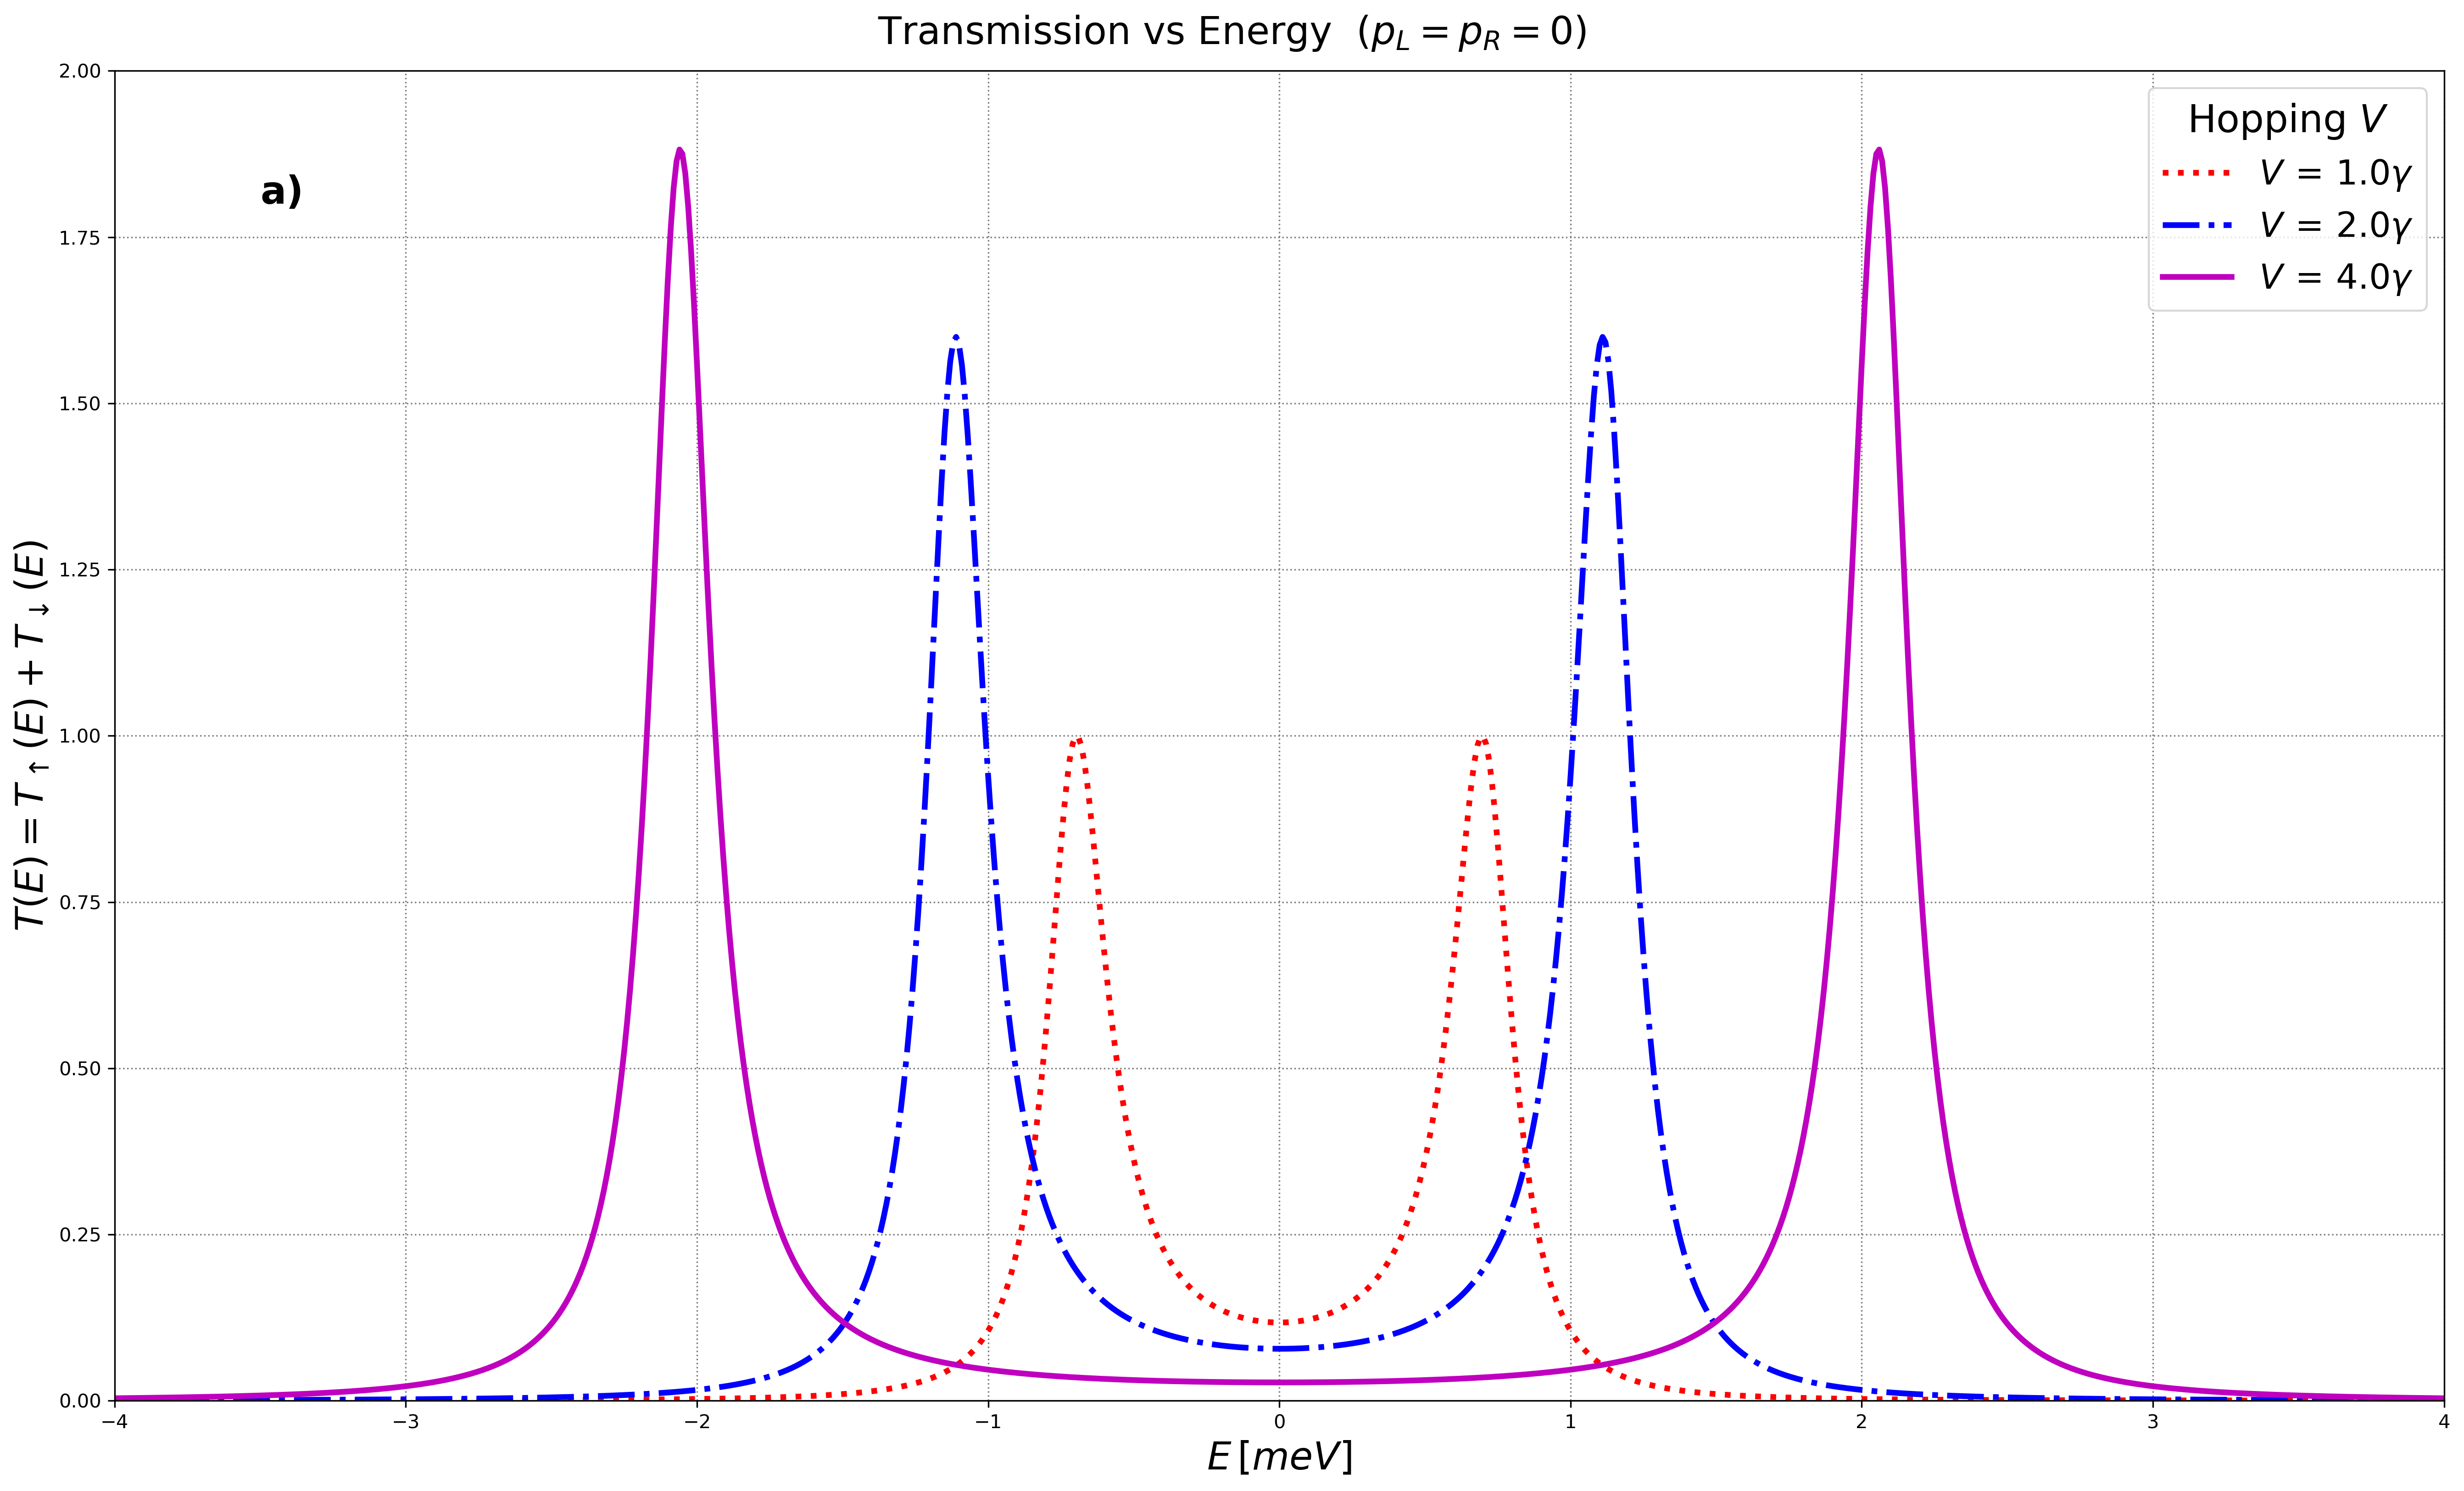

In [12]:
# do not forget constrained_layout=True to have some space between axes
fig = plt.figure(constrained_layout=True, figsize=(18,11), dpi=300)

#Set the grid for the subplots
gs = GridSpec(1, 1, figure=fig)

#Add the subplots
ax1 = fig.add_subplot(gs[0, 0])

#POLARIZATION = 0
# Transmission spin up Plot
p=0

ax1.grid(linestyle=':', color='grey')
################################################################################################################
delta=0
e_1_u = e_1 + delta #meV
e_1_d = e_1 - delta #meV
e_2_u = e_2 + delta #meV
e_2_d = e_2 - delta #meV
v = 1*gamma 

Hamiltonian = np.array([[e_1_u, 0 , v , 0],[0, e_1_d, 0, v], [v, 0, e_2_u, 0], [0, v, 0, e_2_d]], dtype = complex)

ax1.plot(energy_axis, fy.Transmission(energy_axis, gamma, Hamiltonian, p, p)[0]\
     +fy.Transmission(energy_axis, gamma, Hamiltonian, p, p)[1], "r", label=r"$V\,=\,$"+str(v/gamma)+r"$\gamma$", linestyle=":", lw=3)

##################################################################################################################
e_1_u = e_1 + delta #meV
e_1_d = e_1 - delta #meV
e_2_u = e_2 + delta #meV
e_2_d = e_2 - delta #meV
v = 2*gamma 

Hamiltonian = np.array([[e_1_u, 0 , v , 0],[0, e_1_d, 0, v], [v, 0, e_2_u, 0], [0, v, 0, e_2_d]], dtype = complex)

ax1.plot(energy_axis, fy.Transmission(energy_axis, gamma, Hamiltonian, p, p)[0]\
     +fy.Transmission(energy_axis, gamma, Hamiltonian, p, p)[1], "b", label=r"$V\,=\,$"+str(v/gamma)+r"$\gamma$", linestyle="-.", lw=3)

#####################################################################################################################

e_1_u = e_1 + delta #meV
e_1_d = e_1 - delta #meV
e_2_u = e_2 + delta #meV
e_2_d = e_2 - delta #meV
v = 4*gamma 

Hamiltonian = np.array([[e_1_u, 0 , v , 0],[0, e_1_d, 0, v], [v, 0, e_2_u, 0], [0, v, 0, e_2_d]], dtype = complex)

ax1.plot(energy_axis, fy.Transmission(energy_axis, gamma, Hamiltonian, p, p)[0]\
     +fy.Transmission(energy_axis, gamma, Hamiltonian, p, p)[1], "m", label=r"$V\,=\,$"+str(v/gamma)+r"$\gamma$", linestyle="-", lw=3)
##################################################################################################################
ax1.set_xlabel(r'$E\,[meV]$',fontsize=20)
ax1.set_ylabel(r'$T(E) = T_{\uparrow}(E)+T_{\downarrow}(E)$',fontsize=20)
ax1.legend(
    fontsize=18,
    title="Hopping "+r"$V$",
    title_fontsize=20
)
# Etiqueta a)
ax1.text(-3.5, 1.8, 'a)', fontsize=20, fontweight='bold')

# Stablish limits for the subplots
ax1.set_ylim(0, 2)  
ax1.set_xlim(-4, 4)  

# Ajustar el diseño y mostrar los subplots
plt.suptitle("Transmission vs Energy "+r" ($p_{L}=p_{R}=$"+str(p)+")", fontsize=20)
plt.tight_layout()
plt.show()
#fig.savefig('horizontal_Transmission_reference.jpg')

La degeneracion de spin no influye en el efecto CISS, entonces no creo que deba ser incluido en la seccion de resultados, por otro lado, la transmision para diferentes energias de sitio si deberia incluirse.

/home/franklin/miniconda3/envs/py37/lib/python3.7/site-packages/ipykernel_launcher.py:136: UserWarning: This figure was using constrained_layout, but that is incompatible with subplots_adjust and/or tight_layout; disabling constrained_layout.


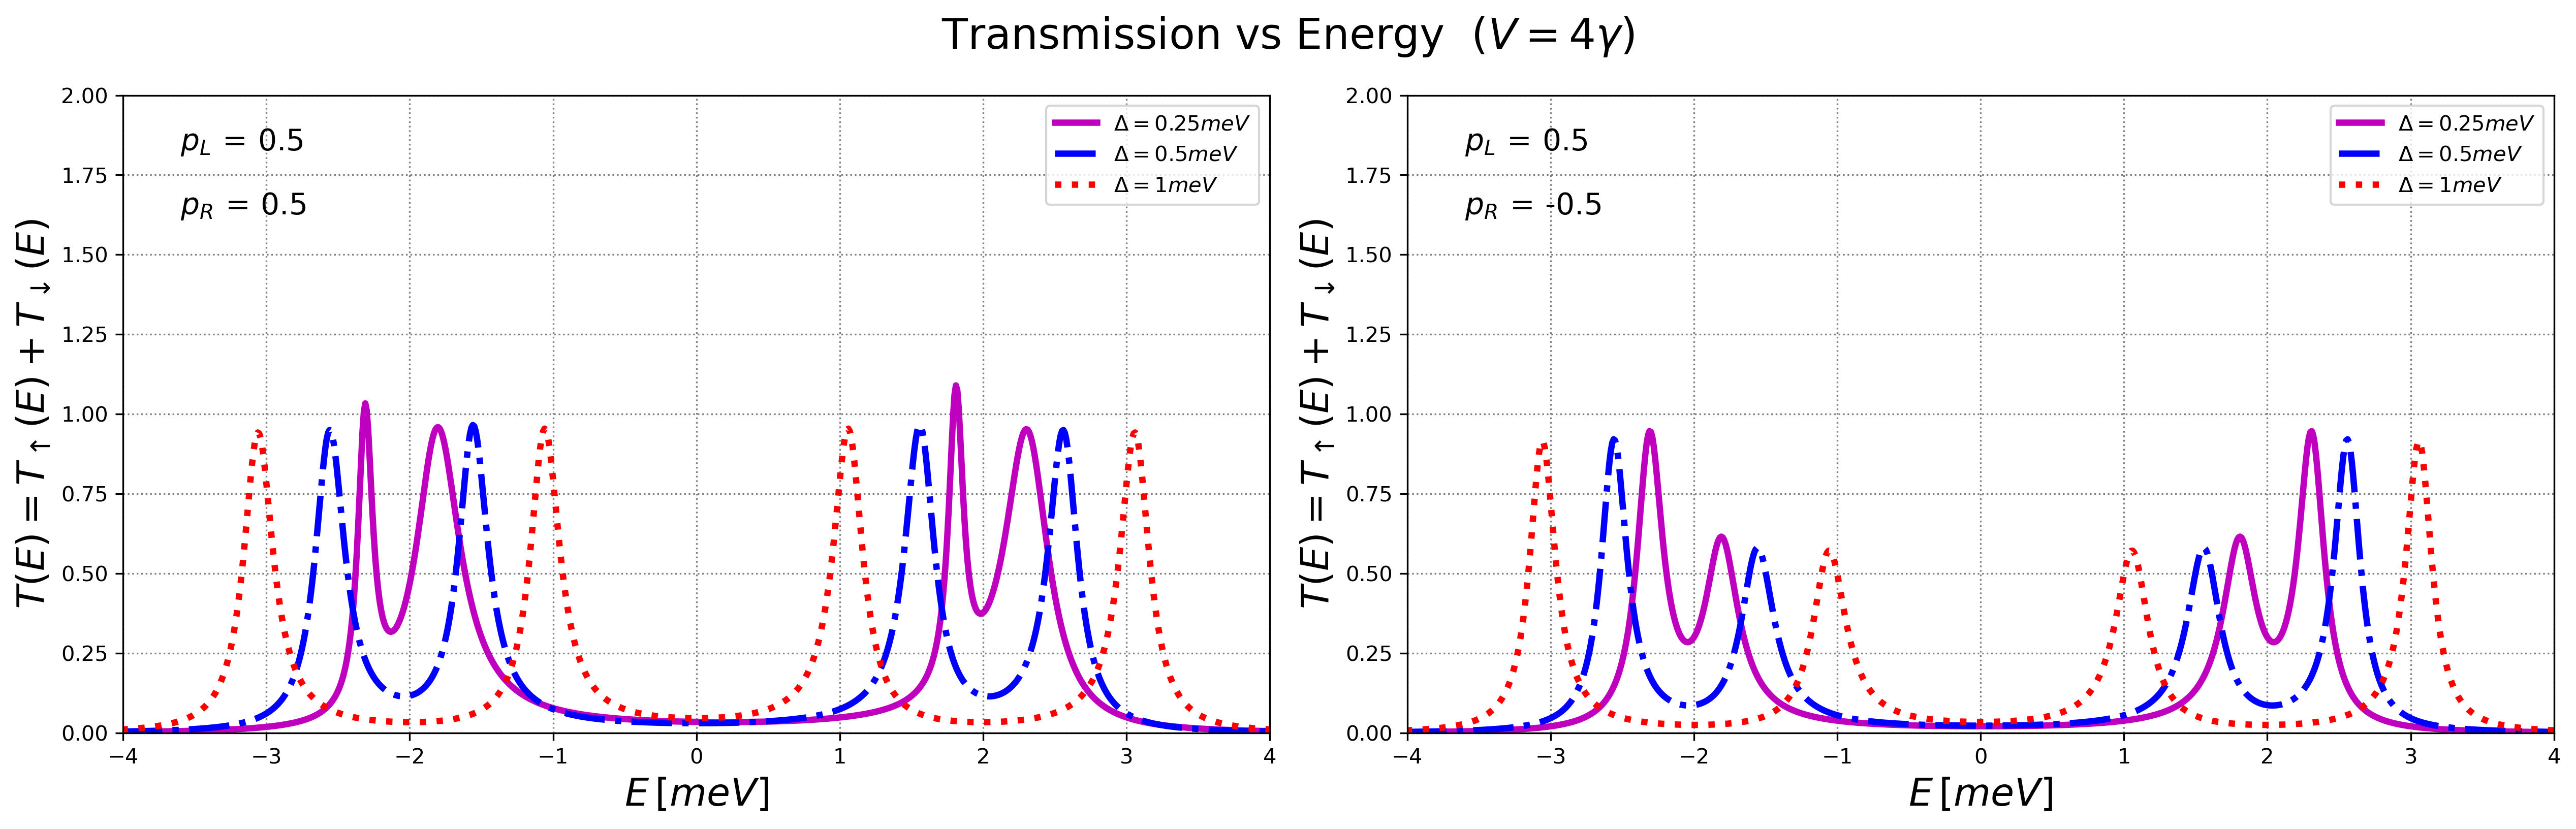

In [13]:
# do not forget constrained_layout=True to have some space between axes
fig = plt.figure(constrained_layout=True, figsize=(17,5.5), dpi=300)

# these are matplotlib.patch.Patch properties
props = dict(boxstyle='round', facecolor='wheat', alpha=0)

#Set the grid for the subplots
gs = GridSpec(1, 2, figure=fig)

#Add the subplots
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])

#POLARIZATION = 0
# Transmission spin up Plot
p_L=0.5
p_R=0.5

#Define the \Delta parameter previously the definition of the Hamiltonian 

ax1.grid(linestyle=':', color='grey')

delta = 0.25 #meV

e_1_u = e_1 + delta #meV
e_1_d = e_1 - delta #meV
e_2_u = e_2 + delta #meV
e_2_d = e_2 - delta #meV
v = 4*gamma 


Hamiltonian = np.array([[e_1_u, 0 , v , 0],[0, e_1_d, 0, v], [v, 0, e_2_u, 0], [0, v, 0, e_2_d]], dtype = complex)

ax1.plot(energy_axis, fy.Transmission(energy_axis, gamma, Hamiltonian, p_L, p_R)[0]\
     +fy.Transmission(energy_axis, gamma, Hamiltonian, p_L, p_R)[1], "m", lw=3, label=r"$\Delta=$"+str(delta)+r"$meV$")

delta = 0.5 #meV

e_1_u = e_1 + delta #meV
e_1_d = e_1 - delta #meV
e_2_u = e_2 + delta #meV
e_2_d = e_2 - delta #meV
v = 4*gamma 

Hamiltonian = np.array([[e_1_u, 0 , v , 0],[0, e_1_d, 0, v], [v, 0, e_2_u, 0], [0, v, 0, e_2_d]], dtype = complex)

ax1.plot(energy_axis, fy.Transmission(energy_axis, gamma, Hamiltonian, p, p)[0]\
     +fy.Transmission(energy_axis, gamma, Hamiltonian, p, p)[1], "b", linestyle="-.",lw=3, label=r"$\Delta=$"+str(delta)+r"$meV$")

delta = 1 #meV

e_1_u = e_1 + delta #meV
e_1_d = e_1 - delta #meV
e_2_u = e_2 + delta #meV
e_2_d = e_2 - delta #meV
v = 4*gamma 


Hamiltonian = np.array([[e_1_u, 0 , v , 0],[0, e_1_d, 0, v], [v, 0, e_2_u, 0], [0, v, 0, e_2_d]], dtype = complex)
ax1.plot(energy_axis, fy.Transmission(energy_axis, gamma, Hamiltonian, p, p)[0]\
     +fy.Transmission(energy_axis, gamma, Hamiltonian, p, p)[1], "r", linestyle=":",lw=3, label=r"$\Delta=$"+str(delta)+r"$meV$")



ax1.set_xlabel(r'$E\,[meV]$',fontsize=18)
ax1.set_ylabel(r'$T(E) = T_{\uparrow}(E)+T_{\downarrow}(E)$',fontsize=18)
ax1.text(0.05, 0.95, r"$p_{L}\,=\,$"+str(p_L), transform=ax1.transAxes, fontsize=14,
        verticalalignment='top', bbox=props)
ax1.text(0.05, 0.85, r"$p_{R}\,=\,$"+str(p_R), transform=ax1.transAxes, fontsize=14,
        verticalalignment='top', bbox=props)
ax1.legend()

##############################################################################################################
p_L= 0.5
p_R = -0.5

#Define the \Delta parameter previously the definition of the Hamiltonian 

ax2.grid(linestyle=':', color='grey')
delta = 0.25 #meV

e_1_u = e_1 + delta #meV
e_1_d = e_1 - delta #meV
e_2_u = e_2 + delta #meV
e_2_d = e_2 - delta #meV
v = 4*gamma 

Hamiltonian = np.array([[e_1_u, 0 , v , 0],[0, e_1_d, 0, v], [v, 0, e_2_u, 0], [0, v, 0, e_2_d]], dtype = complex)
ax2.plot(energy_axis, fy.Transmission(energy_axis, gamma, Hamiltonian, p_L, p_R)[0]\
     +fy.Transmission(energy_axis, gamma, Hamiltonian, p_L, p_R)[1], "m", lw=3, label=r"$\Delta=$"+str(delta)+r"$meV$")

delta = 0.5 #meV

e_1_u = e_1 + delta #meV
e_1_d = e_1 - delta #meV
e_2_u = e_2 + delta #meV
e_2_d = e_2 - delta #meV
v = 4*gamma 

Hamiltonian = np.array([[e_1_u, 0 , v , 0],[0, e_1_d, 0, v], [v, 0, e_2_u, 0], [0, v, 0, e_2_d]], dtype = complex)


ax2.plot(energy_axis, fy.Transmission(energy_axis, gamma, Hamiltonian, p_L, p_R)[0]\
     +fy.Transmission(energy_axis, gamma, Hamiltonian, p_L, p_R)[1], "b", lw=3, linestyle="-.", label=r"$\Delta=$"+str(delta)+r"$meV$")

delta = 1 #meV

e_1_u = e_1 + delta #meV
e_1_d = e_1 - delta #meV
e_2_u = e_2 + delta #meV
e_2_d = e_2 - delta #meV
v = 4*gamma 

Hamiltonian = np.array([[e_1_u, 0 , v , 0],[0, e_1_d, 0, v], [v, 0, e_2_u, 0], [0, v, 0, e_2_d]], dtype = complex)
ax2.plot(energy_axis, fy.Transmission(energy_axis, gamma, Hamiltonian, p_L, p_R)[0]\
     +fy.Transmission(energy_axis, gamma, Hamiltonian, p_L, p_R)[1], "r", lw=3, linestyle=":", label=r"$\Delta=$"+str(delta)+r"$meV$")

ax2.set_xlabel(r'$E\,[meV]$',fontsize=18)
ax2.set_ylabel(r'$T(E) = T_{\uparrow}(E)+T_{\downarrow}(E)$',fontsize=18)
ax2.text(0.05, 0.95, r"$p_{L}\,=\,$"+str(p_L), transform=ax2.transAxes, fontsize=14,
        verticalalignment='top', bbox=props)
ax2.text(0.05, 0.85, r"$p_{R}\,=\,$"+str(p_R), transform=ax2.transAxes, fontsize=14,
        verticalalignment='top', bbox=props)
ax2.legend()

########################################################################################################

# Stablish limits for the subplots
ax1.set_ylim(0, 2)  
ax2.set_ylim(0, 2)   
ax1.set_xlim(-4, 4)  
ax2.set_xlim(-4, 4)   

# Ajustar el diseño y mostrar los subplots
plt.suptitle("Transmission vs Energy "+r" ($V=$"+str(int(v/gamma))+r"$\gamma$)", fontsize=20)
plt.tight_layout()
plt.show()
#fig.savefig('horizontal_Transmission_polarization.jpg')

In [14]:
#Site energies:
e_1 = 0 #meV
e_2 = 0 #meV

gamma_1 = 0.5 #meV
gamma = 10

/home/franklin/miniconda3/envs/py37/lib/python3.7/site-packages/ipykernel_launcher.py:69: UserWarning: This figure was using constrained_layout, but that is incompatible with subplots_adjust and/or tight_layout; disabling constrained_layout.


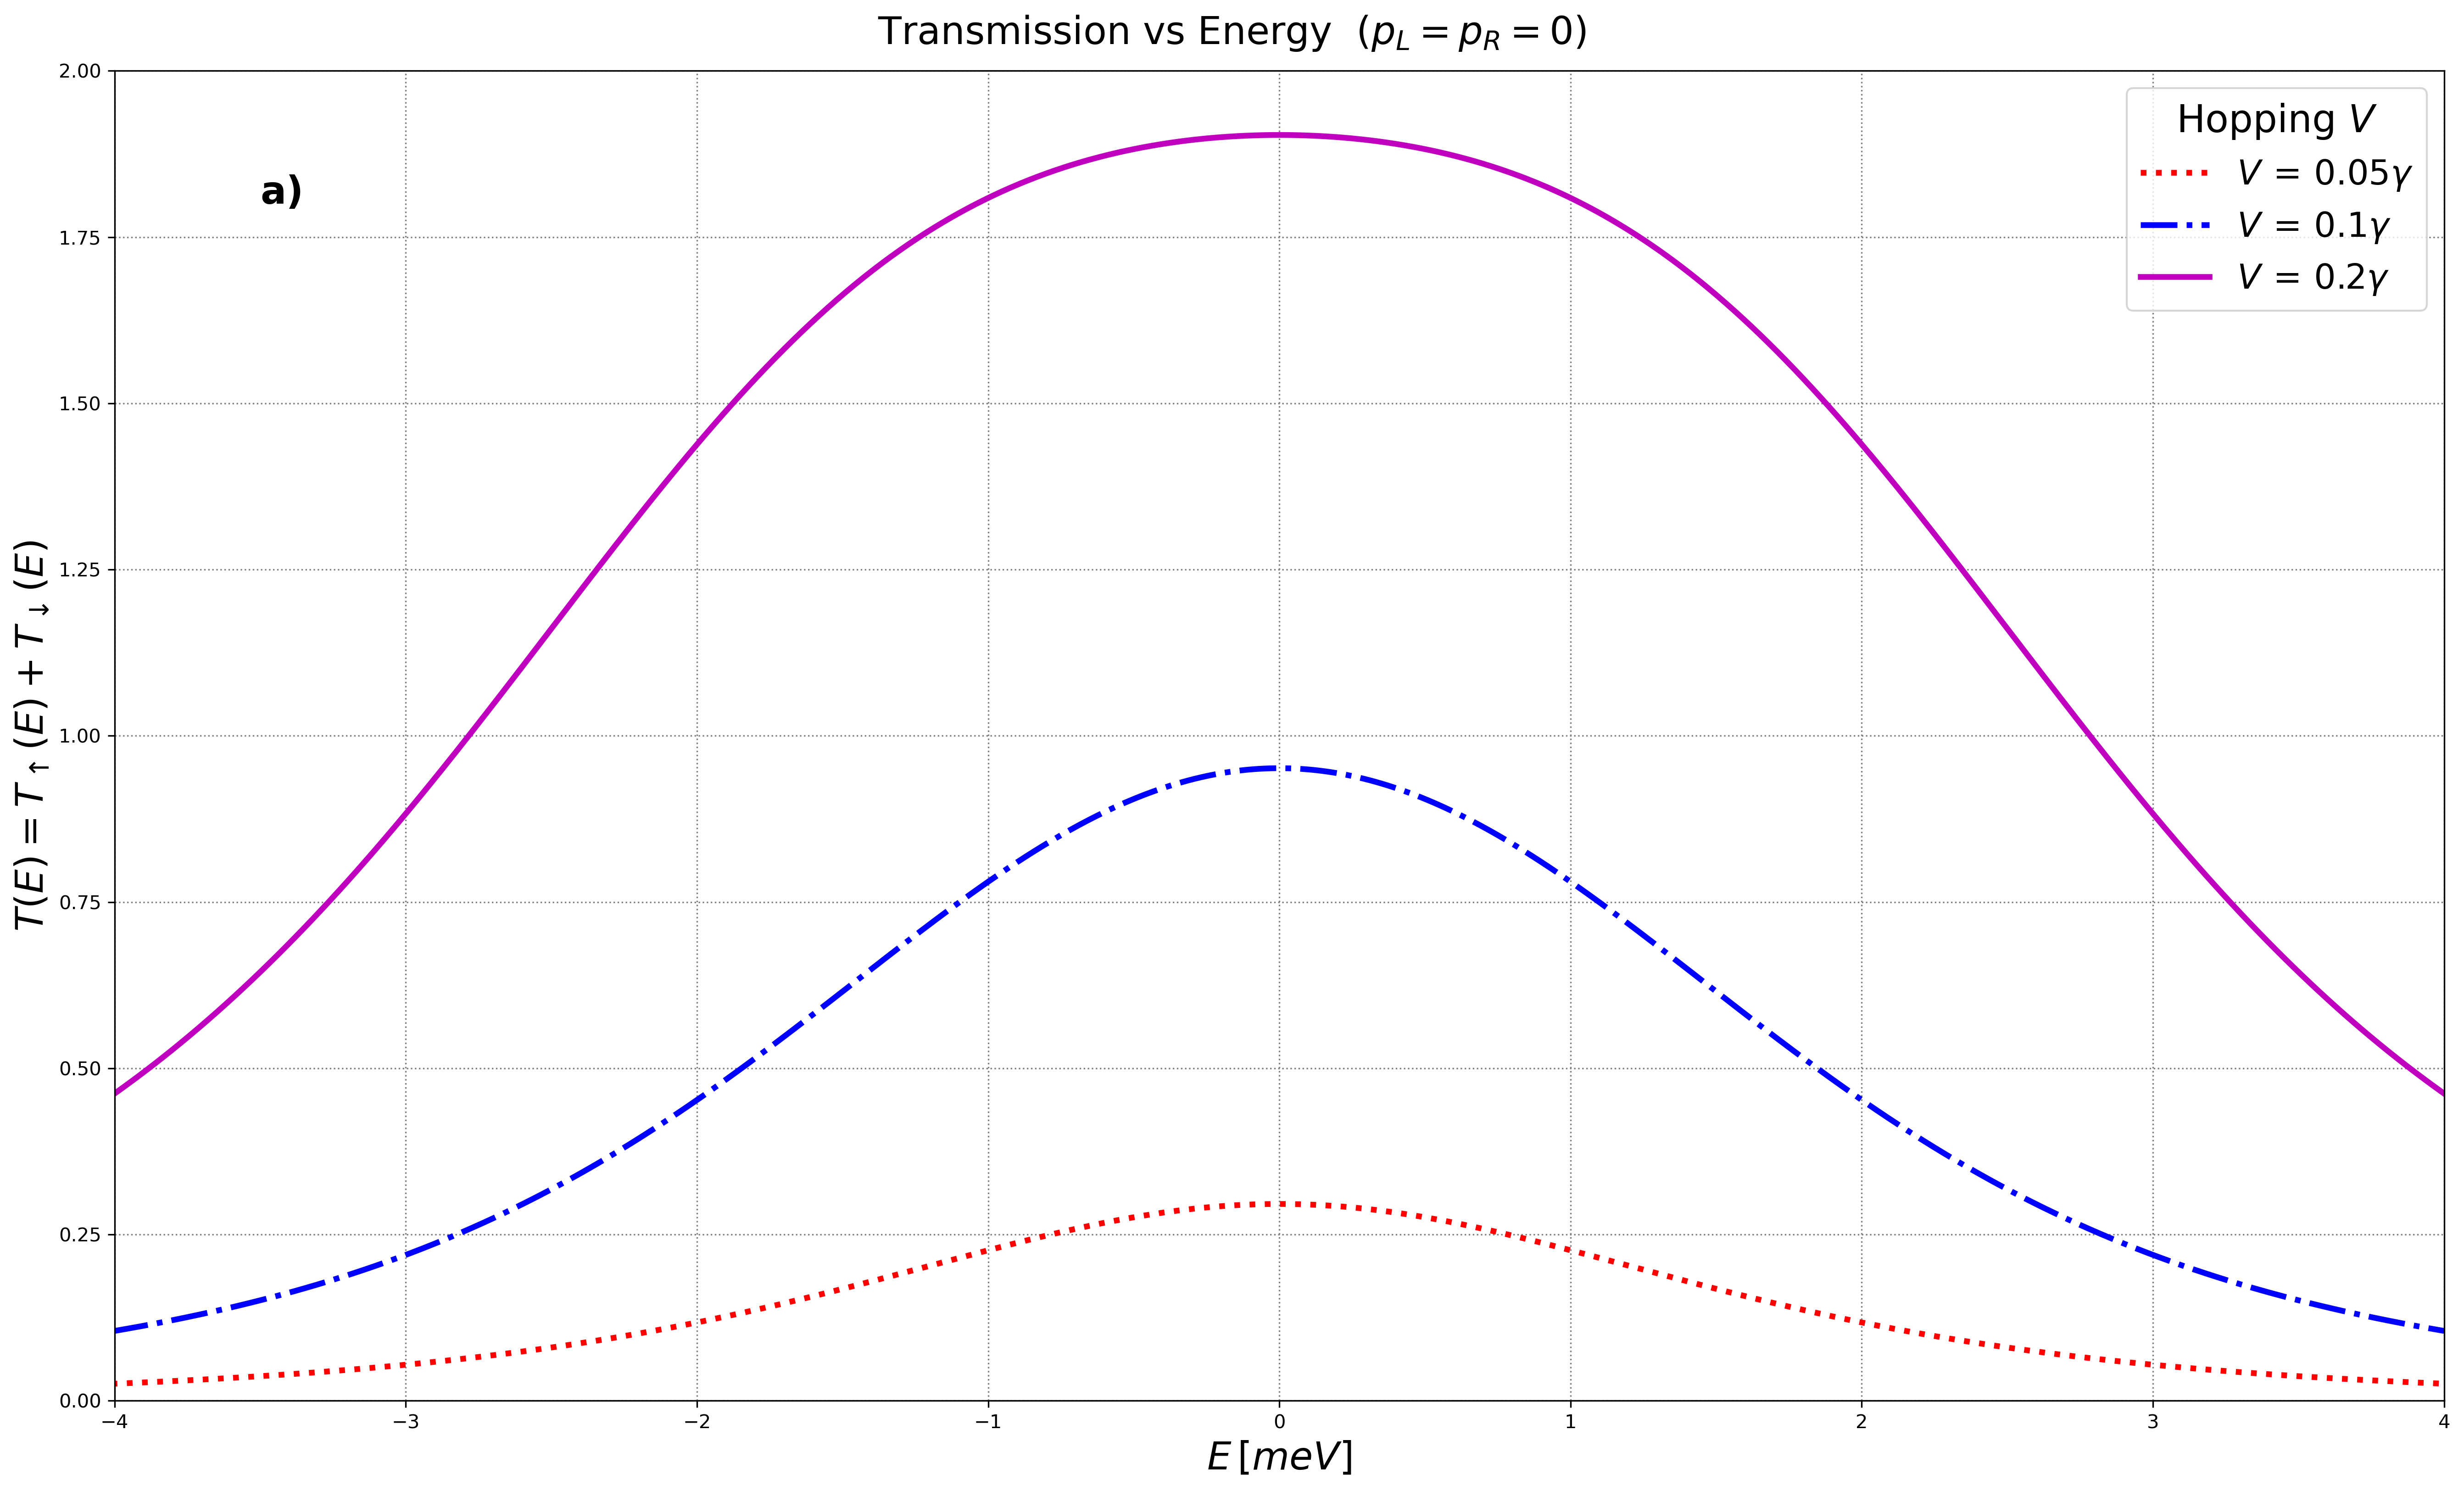

In [15]:
# do not forget constrained_layout=True to have some space between axes
fig = plt.figure(constrained_layout=True, figsize=(18,11), dpi=300)

#Set the grid for the subplots
gs = GridSpec(1, 1, figure=fig)

#Add the subplots
ax1 = fig.add_subplot(gs[0, 0])

#POLARIZATION = 0
# Transmission spin up Plot
p=0

ax1.grid(linestyle=':', color='grey')
################################################################################################################
delta=0
e_1_u = e_1 + delta #meV
e_1_d = e_1 - delta #meV
e_2_u = e_2 + delta #meV
e_2_d = e_2 - delta #meV
v = 1*gamma_1 

Hamiltonian = np.array([[e_1_u, 0 , v , 0],[0, e_1_d, 0, v], [v, 0, e_2_u, 0], [0, v, 0, e_2_d]], dtype = complex)

ax1.plot(energy_axis, fy.Transmission(energy_axis, gamma, Hamiltonian, p, p)[0]\
     +fy.Transmission(energy_axis, gamma, Hamiltonian, p, p)[1], "r", label=r"$V\,=\,$"+str(v/gamma)+r"$\gamma$", linestyle=":", lw=3)

##################################################################################################################
e_1_u = e_1 + delta #meV
e_1_d = e_1 - delta #meV
e_2_u = e_2 + delta #meV
e_2_d = e_2 - delta #meV
v = 2*gamma_1 

Hamiltonian = np.array([[e_1_u, 0 , v , 0],[0, e_1_d, 0, v], [v, 0, e_2_u, 0], [0, v, 0, e_2_d]], dtype = complex)

ax1.plot(energy_axis, fy.Transmission(energy_axis, gamma, Hamiltonian, p, p)[0]\
     +fy.Transmission(energy_axis, gamma, Hamiltonian, p, p)[1], "b", label=r"$V\,=\,$"+str(v/gamma)+r"$\gamma$", linestyle="-.", lw=3)

#####################################################################################################################

e_1_u = e_1 + delta #meV
e_1_d = e_1 - delta #meV
e_2_u = e_2 + delta #meV
e_2_d = e_2 - delta #meV
v = 4*gamma_1 

Hamiltonian = np.array([[e_1_u, 0 , v , 0],[0, e_1_d, 0, v], [v, 0, e_2_u, 0], [0, v, 0, e_2_d]], dtype = complex)

ax1.plot(energy_axis, fy.Transmission(energy_axis, gamma, Hamiltonian, p, p)[0]\
     +fy.Transmission(energy_axis, gamma, Hamiltonian, p, p)[1], "m", label=r"$V\,=\,$"+str(v/gamma)+r"$\gamma$", linestyle="-", lw=3)
##################################################################################################################
ax1.set_xlabel(r'$E\,[meV]$',fontsize=20)
ax1.set_ylabel(r'$T(E) = T_{\uparrow}(E)+T_{\downarrow}(E)$',fontsize=20)
ax1.legend(
    fontsize=18,
    title="Hopping "+r"$V$",
    title_fontsize=20
)
# Etiqueta a)
ax1.text(-3.5, 1.8, 'a)', fontsize=20, fontweight='bold')

# Stablish limits for the subplots
ax1.set_ylim(0, 2)  
ax1.set_xlim(-4, 4)  

# Ajustar el diseño y mostrar los subplots
plt.suptitle("Transmission vs Energy "+r" ($p_{L}=p_{R}=$"+str(p)+")", fontsize=20)
plt.tight_layout()
plt.show()
#fig.savefig('horizontal_Transmission_reference.jpg')